**I note here I=0/1, when defining the Tcc potentials in my code, does not really mean the isospin of physical Tcc. These is inconsistency in the literature!!!!**

In [1]:
using QuadGK, Plots, BenchmarkTools;
using Roots, LaTeXStrings;
using LinearAlgebra: eigvals, eigvecs, eigen;

In [5]:
# set default values for the pyplot backend of Plots
pyplot(frame=:box, minorticks=5, size=(400,300), titlefont = (11,"serif"), 
    guidefont = (12,"serif"), tickfont = (11,"serif"), legendfont= (9, "serif"),
    bg_color_legend = RGBA(1,1,1,0.15), markerstrokecolor= :auto) 

Plots.PyPlotBackend()

In [3]:
include("constants.jl");
include("gem.jl");
include("fts.jl");
include("double_heavy.jl");
include("heavy_antiheavy.jl");

# Double heavy

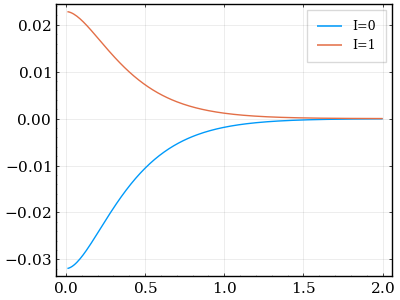

In [6]:
let rv = 0.0:0.01:2.0
    plot(rv, r -> potential_DD(r, 1.0; I = 0), label = "I=0")
    plot!(rv, r -> potential_DD(r, 1.0; I = 1), label = "I=1")
end

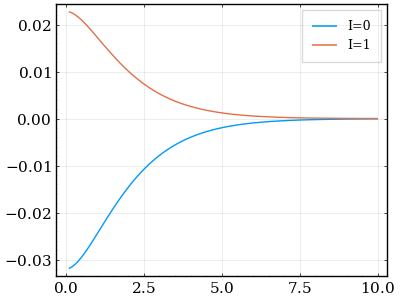

In [7]:
let rv= 0.0:0.1:10.0
    plot(rv, r -> potential_DD(r*hbarc, 1.0; I = 0), label = "I=0")
    plot!(rv, r -> potential_DD(r*hbarc, 1.0; I = 1), label = "I=1")
end

## $D^0D^{*+}\rightarrow D^0D^{*+}$

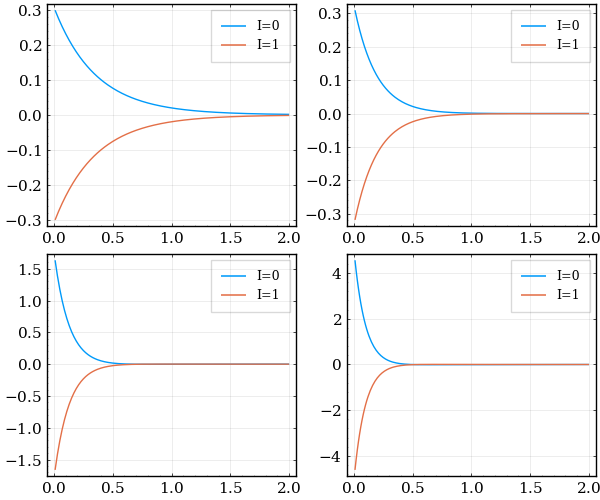

In [8]:
let rv = 0.0:0.01:2.0
    p1 = plot(rv, r -> potential_DnDsc(r, 0.5; I = 0), label = "I=0")
    plot!(rv, r -> potential_DnDsc(r, 0.5; I = 1), label = "I=1")
    p2 = plot(rv, r -> potential_DnDsc(r, 1.0; I = 0), label = "I=0")
    plot!(rv, r -> potential_DnDsc(r, 1.0; I = 1), label = "I=1")
    p3 = plot(rv, r -> potential_DnDsc(r, 1.5; I = 0), label = "I=0")
    plot!(rv, r -> potential_DnDsc(r, 1.5; I = 1), label = "I=1")
    p4 = plot(rv, r -> potential_DnDsc(r, 2.0; I = 0), label = "I=0")
    plot!(rv, r -> potential_DnDsc(r, 2.0; I = 1), label = "I=1")
    plot(p1, p2, p3, p4, layout = (2, 2), size = (600, 500))
end

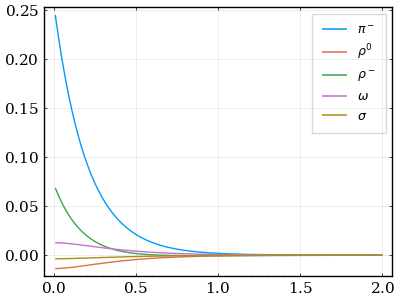

In [9]:
plot(0.0:0.01:2.0, r -> potential_DnDsc(r, 1.0; I = 0, full = false, particle = ["πc"]), label = L"\pi^-")
plot!(0.0:0.01:2.0, r -> potential_DnDsc(r, 1.0; I = 0, full = false, particle = ["ρn"]), label = L"\rho^0")
plot!(0.0:0.01:2.0, r -> potential_DnDsc(r, 1.0; I = 0, full = false, particle = ["ρc"]), label = L"\rho^-")
plot!(0.0:0.01:2.0, r -> potential_DnDsc(r, 1.0; I = 0, full = false, particle = ["ω"]), label = L"\omega")
plot!(0.0:0.01:2.0, r -> potential_DnDsc(r, 1.0; I = 0, full = false, particle = ["σ"]), label = L"\sigma")

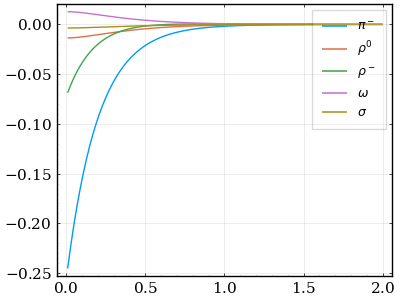

In [10]:
plot(0.0:0.01:2.0, r -> potential_DnDsc(r, 1.0; I = 1, full = false, particle = ["πc"]), label = L"\pi^-")
plot!(0.0:0.01:2.0, r -> potential_DnDsc(r, 1.0; I = 1, full = false, particle = ["ρn"]), label = L"\rho^0")
plot!(0.0:0.01:2.0, r -> potential_DnDsc(r, 1.0; I = 1, full = false, particle = ["ρc"]), label = L"\rho^-")
plot!(0.0:0.01:2.0, r -> potential_DnDsc(r, 1.0; I = 1, full = false, particle = ["ω"]), label = L"\omega")
plot!(0.0:0.01:2.0, r -> potential_DnDsc(r, 1.0; I = 1, full = false, particle = ["σ"]), label = L"\sigma")

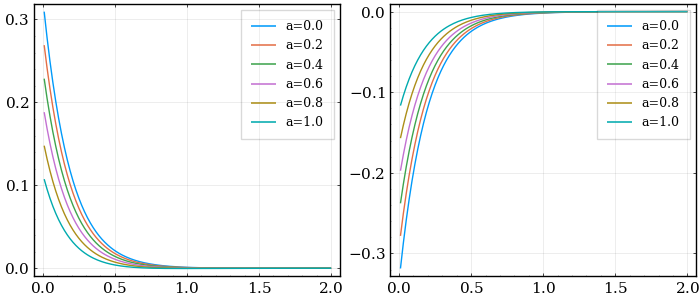

In [11]:
let rv = 0.0:0.01:2.0, av = 0.0:0.2:1.0
    p1 = plot()
    for ai in av
        plot!(rv, r -> potential_DnDsc(r, 1.0; I = 0, a = ai), label = "a=$ai")
    end
    p2 = plot()
    for ai in av
        plot!(rv, r -> potential_DnDsc(r, 1.0; I = 1, a = ai), label = "a=$ai")
    end
    plot(p1, p2, layout = (1, 2), size = (700, 300))
end

## $D^+D^{*0}\rightarrow D^+D^{*0}$

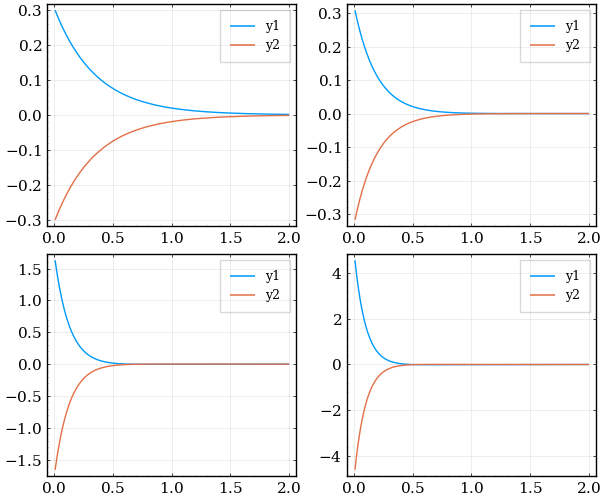

In [12]:
let rv = 0.0:0.01:2.0
    p1 = plot(rv, r -> potential_DcDsn(r, 0.5; I = 0))
    plot!(rv, r -> potential_DcDsn(r, 0.5; I = 1))
    p2 = plot(rv, r -> potential_DcDsn(r, 1.0; I = 0))
    plot!(rv, r -> potential_DcDsn(r, 1.0; I = 1))
    p3 = plot(rv, r -> potential_DcDsn(r, 1.5; I = 0))
    plot!(rv, r -> potential_DcDsn(r, 1.5; I = 1))
    p4 = plot(rv, r -> potential_DcDsn(r, 2.0; I = 0))
    plot!(rv, r -> potential_DcDsn(r, 2.0; I = 1))
    plot(p1, p2, p3, p4, layout = (2, 2), size = (600, 500))
end

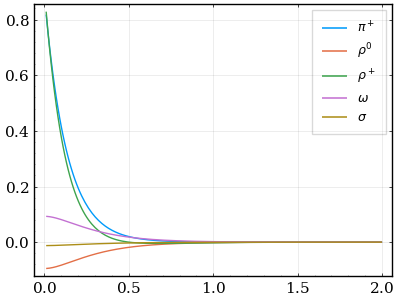

In [13]:
plot(0.0:0.01:2.0, r -> potential_DcDsn(r, 1.5; I = 0, full = false, particle = ["πc"]), label = L"\pi^+")
plot!(0.0:0.01:2.0, r -> potential_DcDsn(r, 1.5; I = 0, full = false, particle = ["ρn"]), label = L"\rho^0")
plot!(0.0:0.01:2.0, r -> potential_DcDsn(r, 1.5; I = 0, full = false, particle = ["ρc"]), label = L"\rho^+")
plot!(0.0:0.01:2.0, r -> potential_DcDsn(r, 1.5; I = 0, full = false, particle = ["ω"]), label = L"\omega")
plot!(0.0:0.01:2.0, r -> potential_DcDsn(r, 1.5; I = 0, full = false, particle = ["σ"]), label = L"\sigma")

## $D^+D^{*0}\rightarrow D^0D^{*+}$

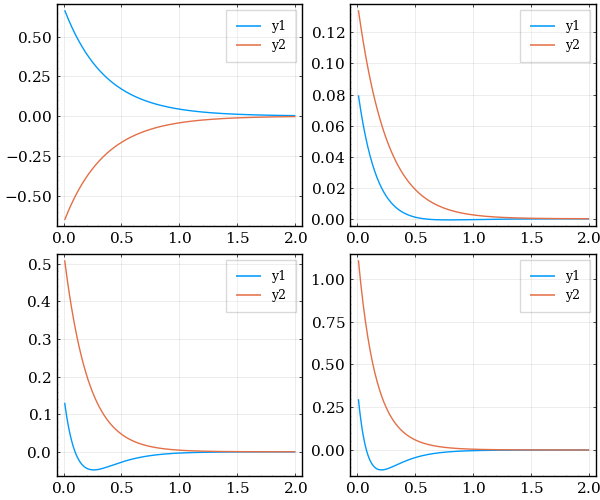

In [14]:
let rv = 0.0:0.01:2.0
    p1 = plot(rv, r -> potential_DDscross(r, 0.5; I = 0))
    plot!(rv, r -> potential_DDscross(r, 0.5; I = 1))
    p2 = plot(rv, r -> potential_DDscross(r, 1.0; I = 0))
    plot!(rv, r -> potential_DDscross(r, 1.0; I = 1))
    p3 = plot(rv, r -> potential_DDscross(r, 1.5; I = 0))
    plot!(rv, r -> potential_DDscross(r, 1.5; I = 1))
    p4 = plot(rv, r -> potential_DDscross(r, 2.0; I = 0))
    plot!(rv, r -> potential_DDscross(r, 2.0; I = 1))
    plot(p1, p2, p3, p4, layout = (2, 2), size = (600, 500))
end

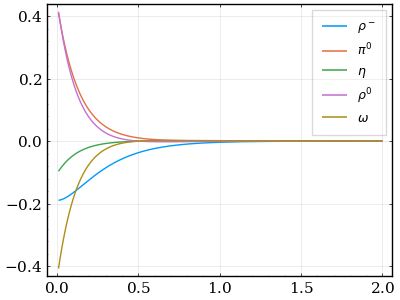

In [15]:
plot(0.0:0.01:2.0, r -> potential_DDscross(r, 1.5; I = 0, full = false, particle = ["ρc"]), label = L"\rho^-")
plot!(0.0:0.01:2.0, r -> potential_DDscross(r, 1.5; I = 0, full = false, particle = ["πn"]), label = L"\pi^0")
plot!(0.0:0.01:2.0, r -> potential_DDscross(r, 1.5; I = 0, full = false, particle = ["η"]), label = L"\eta")
plot!(0.0:0.01:2.0, r -> potential_DDscross(r, 1.5; I = 0, full = false, particle = ["ρn"]), label = L"\rho^0")
plot!(0.0:0.01:2.0, r -> potential_DDscross(r, 1.5; I = 0, full = false, particle = ["ω"]), label = L"\omega")

## under isospin basis

In [16]:
function potential_Tcc_detailed(r, Λ; a = 0.0, st = [1, 0], particle = "π")
    res = 0.0
    if particle == "π"
        res = (potential_DnDsc(r, Λ; I = 1, a = a, st = st, full = false, particle = ["πc"])
               -
               2 * potential_DDscross(r, Λ; I = 1, a = a, st = st, full = false, particle = ["πn"]) + potential_DcDsn(r, Λ; I = 1, a = a, st = st, full = false, particle = ["πc"]))
    elseif particle == "ρ"
        res = (potential_DnDsc(r, Λ; I = 1, a = a, st = st, full = false, particle = ["ρn", "ρc"])
               -
               2 * potential_DDscross(r, Λ; I = 1, a = a, st = st, full = false, particle = ["ρc", "ρn"]) + potential_DcDsn(r, Λ; I = 1, a = a, st = st, full = false, particle = ["ρn", "ρc"]))
    elseif particle == "ω"
        res = (potential_DnDsc(r, Λ; I = 1, a = a, st = st, full = false, particle = ["ω"])
               -
               2 * potential_DDscross(r, Λ; I = 1, a = a, st = st, full = false, particle = ["ω"]) + potential_DcDsn(r, Λ; I = 1, a = a, st = st, full = false, particle = ["ω"]))
    elseif particle == "η"
        res = (potential_DnDsc(r, Λ; I = 1, a = a, st = st, full = false, particle = ["η"])
               -
               2 * potential_DDscross(r, Λ; I = 1, a = a, st = st, full = false, particle = ["η"]) + potential_DcDsn(r, Λ; I = 1, a = a, st = st, full = false, particle = ["η"]))
    elseif particle == "σ"
        res = (potential_DnDsc(r, Λ; I = 1, a = a, st = st, full = false, particle = ["σ"]) + potential_DcDsn(r, Λ; I = 1, a = a, st = st, full = false, particle = ["σ"]))
    end
    return res / 2.0
end

potential_Tcc_detailed (generic function with 1 method)

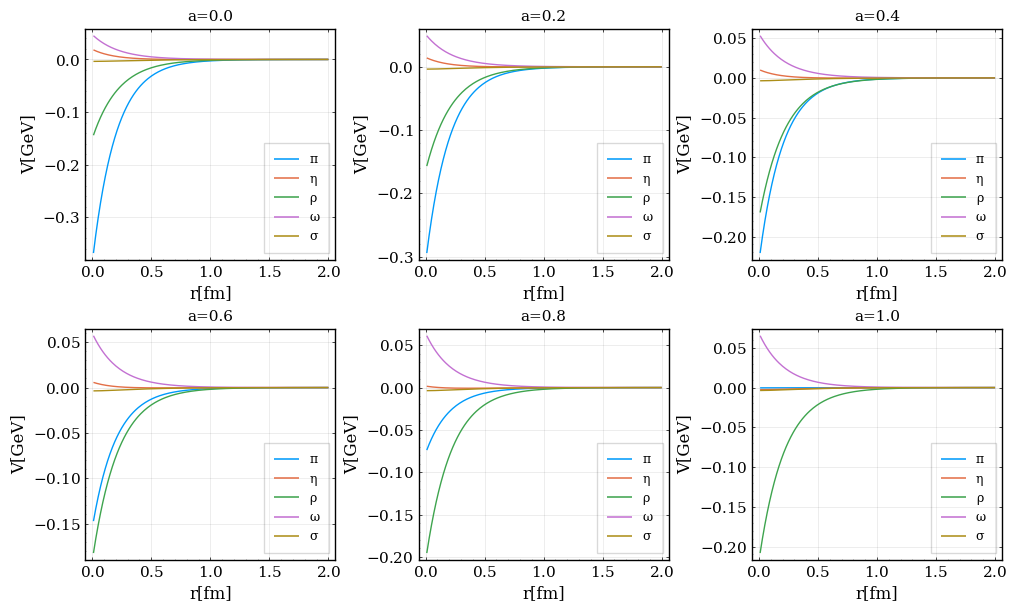

"/Users/linqiu/Nutstore Files/Nutstore/Projects/gitrepos/Tcc/SHE/images/potentials/potential_tcc_detailed.png"

In [18]:
let rv = 0.0:0.01:2.0, Λ = 1.0, st = [1, 0], av = collect(0.0:0.2:1.0)
    plt = Vector{Any}(undef, 6)
    for i in 1:6
        plt[i] = plot(xlabel="r[fm]",ylabel="V[GeV]",title = "a=$(av[i])", legend = :bottomright)
        plot!(rv, r -> potential_Tcc_detailed(r, Λ; a = av[i], st = st, particle = "π"), label = "π")
        plot!(rv, r -> potential_Tcc_detailed(r, Λ; a = av[i], st = st, particle = "η"), label = "η")
        plot!(rv, r -> potential_Tcc_detailed(r, Λ; a = av[i], st = st, particle = "ρ"), label = "ρ")
        plot!(rv, r -> potential_Tcc_detailed(r, Λ; a = av[i], st = st, particle = "ω"), label = "ω")
        plot!(rv, r -> potential_Tcc_detailed(r, Λ; a = av[i], st = st, particle = "σ"), label = "σ")
    end
    plot(plt..., layout = (2, 3), size = (1000, 600))
    savefig("./images/potentials/potential_tcc_detailed.png")
end

In [19]:
function potential_isospin(r, Λ; I = 0, sig = 0, a = 0.0, st = [1, 0], particle = "obe")
    res = 0.0
    if I == 0 && sig == 0
        if particle == "obe"
            res = potential_DnDsc(r, Λ; I = 1, a = a, st = st) - 2 * potential_DDscross(r, Λ; I = 1, a = a, st = st) + potential_DcDsn(r, Λ; I = 1, a = a, st = st)
        elseif particle == "ope"
            res = (potential_DnDsc(r, Λ; I = 1, a = a, st = st, full = false, particle = ["πc"])
                   -
                   2 * potential_DDscross(r, Λ; I = 1, a = a, st = st, full = false, particle = ["πn"]) + potential_DcDsn(r, Λ; I = 1, a = a, st = st, full = false, particle = ["πc"]))
        else
            res = (potential_DnDsc(r, Λ; I = 1, a = a, st = st, full = false, particle = ["ρn", "ω", "σ", "ρc"])
                   -
                   2 * potential_DDscross(r, Λ; I = 1, a = a, st = st, full = false, particle = ["ρc", "η", "ρn", "ω"]) + potential_DcDsn(r, Λ; I = 1, a = a, st = st, full = false, particle = ["ρn", "ω", "σ", "ρc"]))
        end
    elseif I == 0 && sig == 1
        if particle == "obe"
            res = potential_DnDsc(r, Λ; I = 0, a = a, st = st) + 2 * potential_DDscross(r, Λ; I = 0, a = a, st = st) + potential_DcDsn(r, Λ; I = 0, a = a, st = st)
        elseif particle == "ope"
            res = (potential_DnDsc(r, Λ; I = 0, a = a, st = st, full = false, particle = ["πc"])
                   + 2 * potential_DDscross(r, Λ; I = 0, a = a, st = st, full = false, particle = ["πn"]) + potential_DcDsn(r, Λ; I = 0, a = a, st = st, full = false, particle = ["πc"]))
        else
            res = (potential_DnDsc(r, Λ; I = 0, a = a, st = st, full = false, particle = ["ρn", "ω", "σ", "ρc"])
                   + 2 * potential_DDscross(r, Λ; I = 0, a = a, st = st, full = false, particle = ["ρc", "η", "ρn", "ω"]) + potential_DcDsn(r, Λ; I = 0, a = a, st = st, full = false, particle = ["ρn", "ω", "σ", "ρc"]))
        end
    elseif I == 1 && sig == 0
        if particle == "obe"
            res = potential_DnDsc(r, Λ; I = 0, a = a, st = st) - 2 * potential_DDscross(r, Λ; I = 0, a = a, st = st) + potential_DcDsn(r, Λ; I = 0, a = a, st = st)
        elseif particle == "ope"
            res = (potential_DnDsc(r, Λ; I = 0, a = a, st = st, full = false, particle = ["πc"])
                   -
                   2 * potential_DDscross(r, Λ; I = 0, a = a, st = st, full = false, particle = ["πn"]) + potential_DcDsn(r, Λ; I = 0, a = a, st = st, full = false, particle = ["πc"]))
        else
            res = (potential_DnDsc(r, Λ; I = 0, a = a, st = st, full = false, particle = ["ρn", "ω", "σ", "ρc"])
                   -
                   2 * potential_DDscross(r, Λ; I = 0, a = a, st = st, full = false, particle = ["ρc", "η", "ρn", "ω"]) + potential_DcDsn(r, Λ; I = 0, a = a, st = st, full = false, particle = ["ρn", "ω", "σ", "ρc"]))
        end
    else
        if particle == "obe"
            res = potential_DnDsc(r, Λ; I = 1, a = a, st = st) + 2 * potential_DDscross(r, Λ; I = 1, a = a, st = st) + potential_DcDsn(r, Λ; I = 1, a = a, st = st)
        elseif particle == "ope"
            res = (potential_DnDsc(r, Λ; I = 1, a = a, st = st, full = false, particle = ["πc"])
                   + 2 * potential_DDscross(r, Λ; I = 1, a = a, st = st, full = false, particle = ["πn"]) + potential_DcDsn(r, Λ; I = 1, a = a, st = st, full = false, particle = ["πc"]))
        else
            res = (potential_DnDsc(r, Λ; I = 1, a = a, st = st, full = false, particle = ["ρn", "ω", "σ", "ρc"])
                   + 2 * potential_DDscross(r, Λ; I = 1, a = a, st = st, full = false, particle = ["ρc", "η", "ρn", "ω"]) + potential_DcDsn(r, Λ; I = 1, a = a, st = st, full = false, particle = ["ρn", "ω", "σ", "ρc"]))
        end
    end
    return res / 2.0
end

potential_isospin (generic function with 1 method)

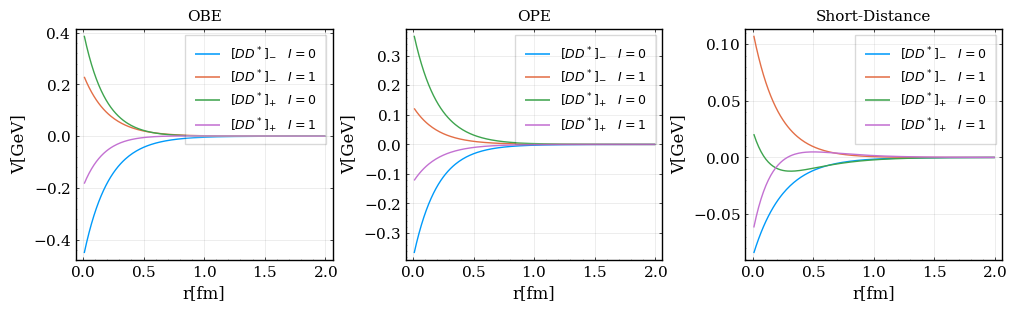

"/Users/linqiu/Nutstore Files/Nutstore/Projects/gitrepos/Tcc/SHE/images/potentials/potential_tcc_partners_bpc.png"

In [20]:
let rv = 0.0:0.01:2.0, Λ = 1.0
    p1 = plot(xlabel="r[fm]",ylabel="V[GeV]",title = "OBE")
    plot!(rv, r -> potential_isospin(r, Λ; I = 0, sig = 0, a = 0.0, st = [1, 0], particle = "obe"), label = L"[DD^*]_{-}\quad I=0")
    plot!(rv, r -> potential_isospin(r, Λ; I = 1, sig = 0, a = 0.0, st = [1, 0], particle = "obe"), label = L"[DD^*]_{-}\quad I=1")
    plot!(rv, r -> potential_isospin(r, Λ; I = 0, sig = 1, a = 0.0, st = [1, 0], particle = "obe"), label = L"[DD^*]_{+}\quad I=0")
    plot!(rv, r -> potential_isospin(r, Λ; I = 1, sig = 1, a = 0.0, st = [1, 0], particle = "obe"), label = L"[DD^*]_{+}\quad I=1")
    p2 = plot(xlabel="r[fm]",ylabel="V[GeV]",title = "OPE")
    plot!(rv, r -> potential_isospin(r, Λ; I = 0, sig = 0, a = 0.0, st = [1, 0], particle = "ope"), label = L"[DD^*]_{-}\quad I=0")
    plot!(rv, r -> potential_isospin(r, Λ; I = 1, sig = 0, a = 0.0, st = [1, 0], particle = "ope"), label = L"[DD^*]_{-}\quad I=1")
    plot!(rv, r -> potential_isospin(r, Λ; I = 0, sig = 1, a = 0.0, st = [1, 0], particle = "ope"), label = L"[DD^*]_{+}\quad I=0")
    plot!(rv, r -> potential_isospin(r, Λ; I = 1, sig = 1, a = 0.0, st = [1, 0], particle = "ope"), label = L"[DD^*]_{+}\quad I=1")
    p3 = plot(xlabel="r[fm]",ylabel="V[GeV]",title = "Short-Distance")
    plot!(rv, r -> potential_isospin(r, Λ; I = 0, sig = 0, a = 0.0, st = [1, 0], particle = "contact"), label = L"[DD^*]_{-}\quad I=0")
    plot!(rv, r -> potential_isospin(r, Λ; I = 1, sig = 0, a = 0.0, st = [1, 0], particle = "contact"), label = L"[DD^*]_{-}\quad I=1")
    plot!(rv, r -> potential_isospin(r, Λ; I = 0, sig = 1, a = 0.0, st = [1, 0], particle = "contact"), label = L"[DD^*]_{+}\quad I=0")
    plot!(rv, r -> potential_isospin(r, Λ; I = 1, sig = 1, a = 0.0, st = [1, 0], particle = "contact"), label = L"[DD^*]_{+}\quad I=1")

    plot(p1, p2, p3, layout = (1, 3), size = (1000, 300))
    savefig("./images/potentials/potential_tcc_partners_bpc.png")
end

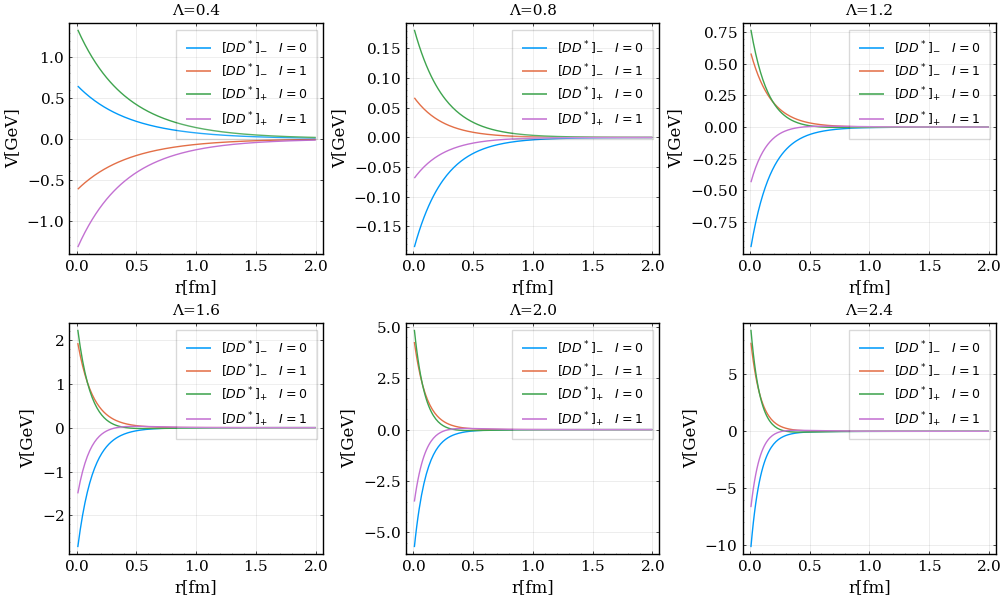

In [21]:
let rv = 0.0:0.01:2.0, Λv = collect(0.4:0.4:2.4)
    plt = Vector{Any}(undef, length(Λv))
    for i in 1:length(Λv)
        plt[i]= plot(title="Λ=$(Λv[i])",xlabel="r[fm]",ylabel="V[GeV]")
        plot!(rv, r -> potential_isospin(r, Λv[i]; I = 0, sig = 0, a = 0.0, st = [1, 0], particle = "obe"), label = L"[DD^*]_{-}\quad I=0")
        plot!(rv, r -> potential_isospin(r, Λv[i]; I = 1, sig = 0, a = 0.0, st = [1, 0], particle = "obe"), label = L"[DD^*]_{-}\quad I=1")
        plot!(rv, r -> potential_isospin(r, Λv[i]; I = 0, sig = 1, a = 0.0, st = [1, 0], particle = "obe"), label = L"[DD^*]_{+}\quad I=0")
        plot!(rv, r -> potential_isospin(r, Λv[i]; I = 1, sig = 1, a = 0.0, st = [1, 0], particle = "obe"), label = L"[DD^*]_{+}\quad I=1")
    end
    plot(plt..., layout = (2, 3), size = (1000, 600))
end

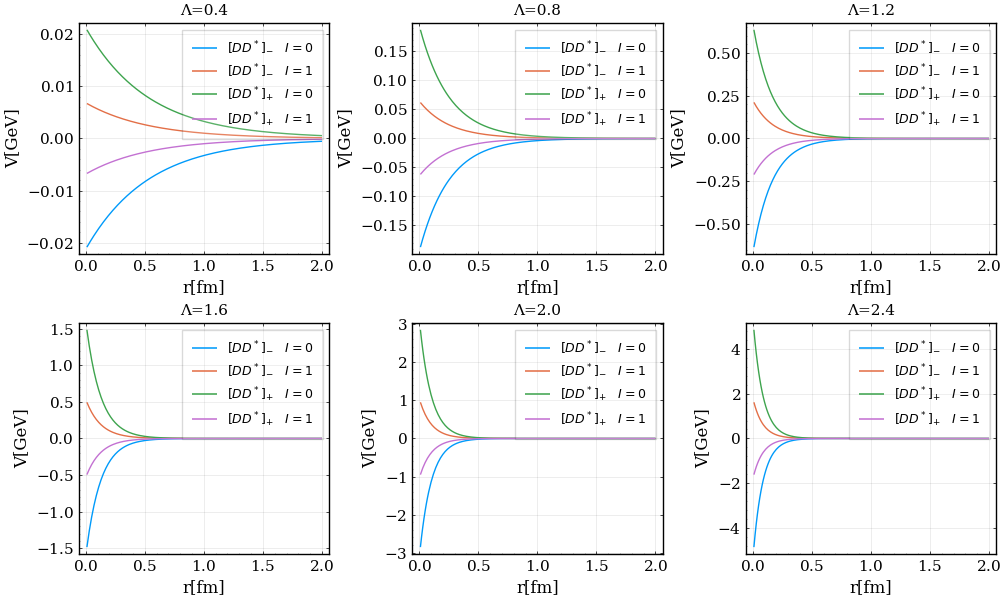

In [22]:
let rv = 0.0:0.01:2.0, Λv = collect(0.4:0.4:2.4)
    plt = Vector{Any}(undef, length(Λv))
    for i in 1:length(Λv)
        plt[i]= plot(title="Λ=$(Λv[i])",xlabel="r[fm]",ylabel="V[GeV]")
        plot!(rv, r -> potential_isospin(r, Λv[i]; I = 0, sig = 0, a = 0.0, st = [1, 0], particle = "ope"), label = L"[DD^*]_{-}\quad I=0")
        plot!(rv, r -> potential_isospin(r, Λv[i]; I = 1, sig = 0, a = 0.0, st = [1, 0], particle = "ope"), label = L"[DD^*]_{-}\quad I=1")
        plot!(rv, r -> potential_isospin(r, Λv[i]; I = 0, sig = 1, a = 0.0, st = [1, 0], particle = "ope"), label = L"[DD^*]_{+}\quad I=0")
        plot!(rv, r -> potential_isospin(r, Λv[i]; I = 1, sig = 1, a = 0.0, st = [1, 0], particle = "ope"), label = L"[DD^*]_{+}\quad I=1")
    end
    plot(plt..., layout = (2, 3), size = (1000, 600))
end

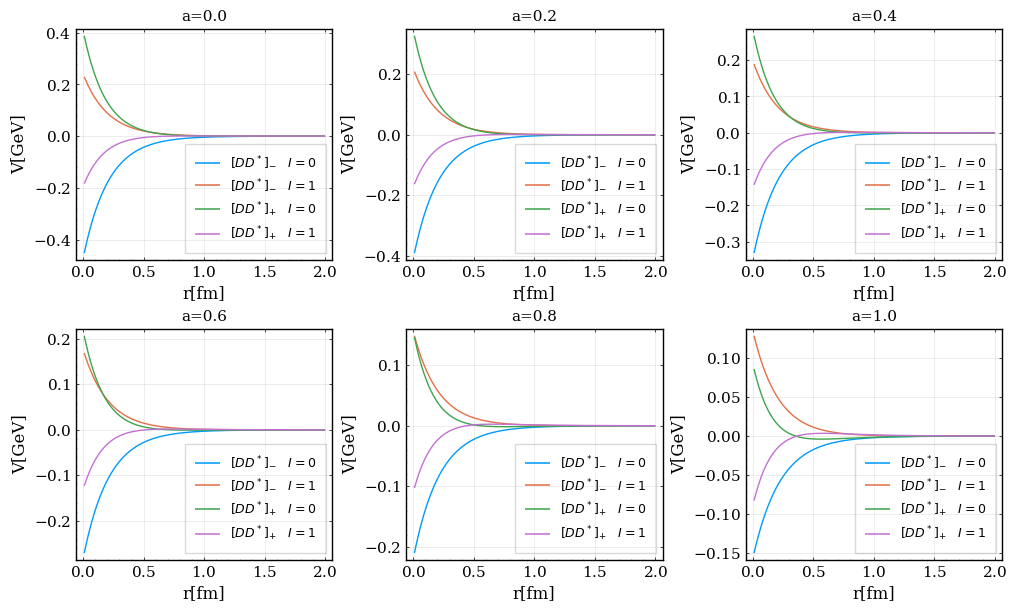

"/Users/linqiu/Nutstore Files/Nutstore/Projects/gitrepos/Tcc/SHE/images/potentials/potential_tcc_partners_ss.png"

In [23]:
# S->S
let rv = 0.0:0.01:2.0, Λ = 1.0, av = collect(0.0:0.2:1.0)
    plt = Vector{Any}(undef, 6)
    for i in 1:1:6
        plt[i] = plot(xlabel="r[fm]",ylabel="V[GeV]",title = "a=$(av[i])",legend=:bottomright)
        plot!(rv, r -> potential_isospin(r, Λ; I = 0, sig = 0, a = av[i], st = [1, 0], particle = "obe"), label = L"[DD^*]_{-}\quad I=0")
        plot!(rv, r -> potential_isospin(r, Λ; I = 1, sig = 0, a = av[i], st = [1, 0], particle = "obe"), label = L"[DD^*]_{-}\quad I=1")
        plot!(rv, r -> potential_isospin(r, Λ; I = 0, sig = 1, a = av[i], st = [1, 0], particle = "obe"), label = L"[DD^*]_{+}\quad I=0")
        plot!(rv, r -> potential_isospin(r, Λ; I = 1, sig = 1, a = av[i], st = [1, 0], particle = "obe"), label = L"[DD^*]_{+}\quad I=1")
    end
    plot(plt..., layout = (2, 3), size = (1000, 600))
    savefig("./images/potentials/potential_tcc_partners_ss.png")
end

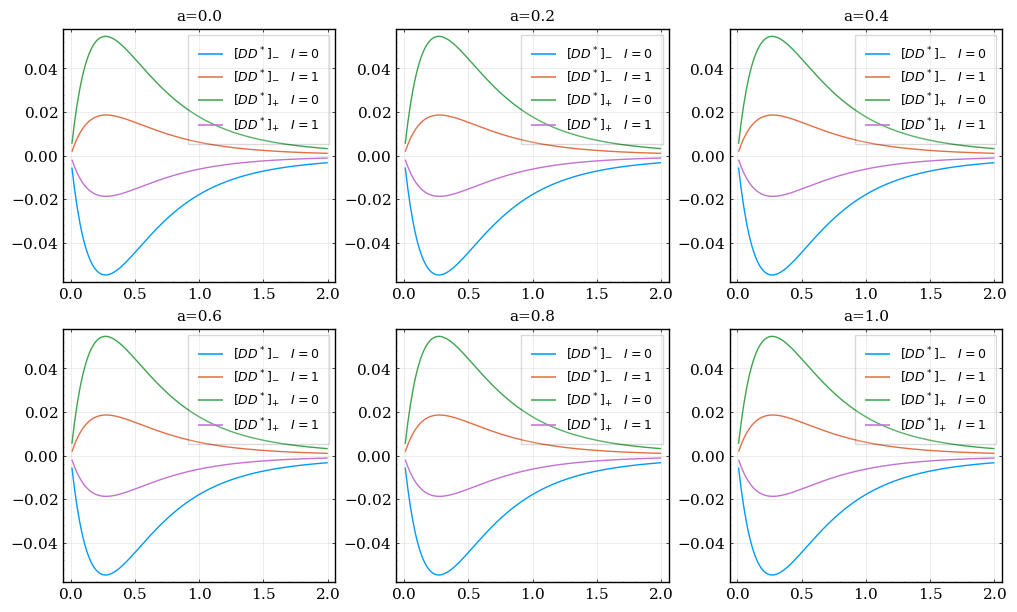

"/Users/linqiu/Nutstore Files/Nutstore/Projects/gitrepos/Tcc/SHE/images/potentials/potential_tcc_partners_sd.png"

In [24]:
# S->D
let rv = 0.0:0.01:2.0, Λ = 1.0, av = collect(0.0:0.2:1.0)
    plt = Vector{Any}(undef, 6)
    for i in 1:1:6
        plt[i] = plot(title = "a=$(av[i])")
        plot!(rv, r -> potential_isospin(r, Λ; I = 0, sig = 0, a = av[i], st = [0, -sqrt(2)], particle = "obe"), label = L"[DD^*]_{-}\quad I=0")
        plot!(rv, r -> potential_isospin(r, Λ; I = 1, sig = 0, a = av[i], st = [0, -sqrt(2)], particle = "obe"), label = L"[DD^*]_{-}\quad I=1")
        plot!(rv, r -> potential_isospin(r, Λ; I = 0, sig = 1, a = av[i], st = [0, -sqrt(2)], particle = "obe"), label = L"[DD^*]_{+}\quad I=0")
        plot!(rv, r -> potential_isospin(r, Λ; I = 1, sig = 1, a = av[i], st = [0, -sqrt(2)], particle = "obe"), label = L"[DD^*]_{+}\quad I=1")
    end
    plot(plt..., layout = (2, 3), size = (1000, 600))
    savefig("./images/potentials/potential_tcc_partners_sd.png")
end

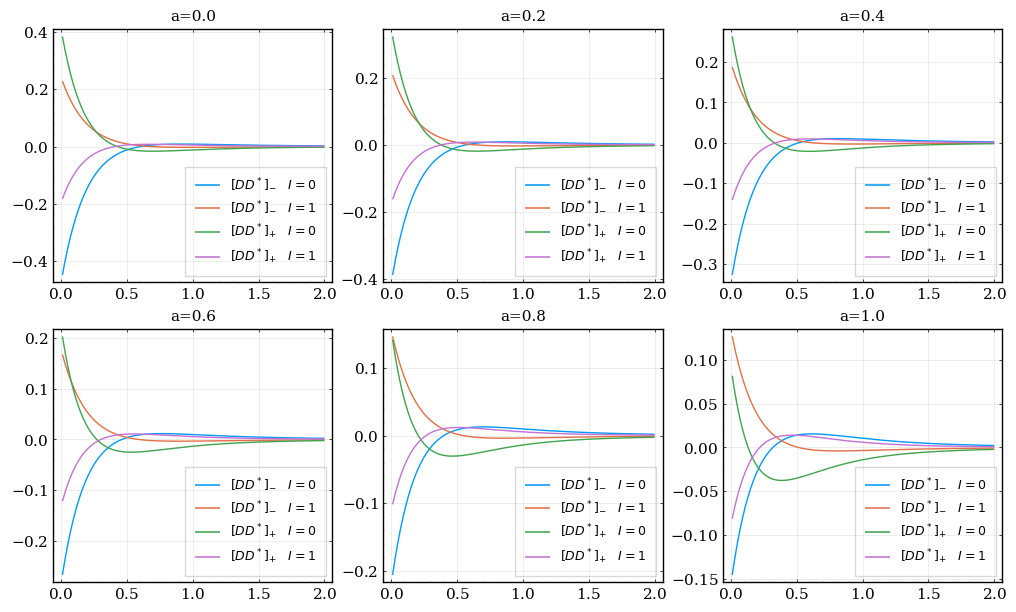

"/Users/linqiu/Nutstore Files/Nutstore/Projects/gitrepos/Tcc/SHE/images/potentials/potential_tcc_partners_dd.png"

In [25]:
# D->D
let rv = 0.0:0.01:2.0, Λ = 1.0, av = collect(0.0:0.2:1.0)
    plt = Vector{Any}(undef, 6)
    for i in 1:1:6
        plt[i] = plot(title = "a=$(av[i])",legend=:bottomright)
        plot!(rv, r -> potential_isospin(r, Λ; I = 0, sig = 0, a = av[i], st = [1, 1], particle = "obe"), label = L"[DD^*]_{-}\quad I=0")
        plot!(rv, r -> potential_isospin(r, Λ; I = 1, sig = 0, a = av[i], st = [1, 1], particle = "obe"), label = L"[DD^*]_{-}\quad I=1")
        plot!(rv, r -> potential_isospin(r, Λ; I = 0, sig = 1, a = av[i], st = [1, 1], particle = "obe"), label = L"[DD^*]_{+}\quad I=0")
        plot!(rv, r -> potential_isospin(r, Λ; I = 1, sig = 1, a = av[i], st = [1, 1], particle = "obe"), label = L"[DD^*]_{+}\quad I=1")
    end
    plot(plt..., layout = (2, 3), size = (1000, 600))
    savefig("./images/potentials/potential_tcc_partners_dd.png")
end

# heavy-antiheavy

## $[D^0\bar{D}^{*0}\rightarrow [D^0\bar{D}^{*0}]$

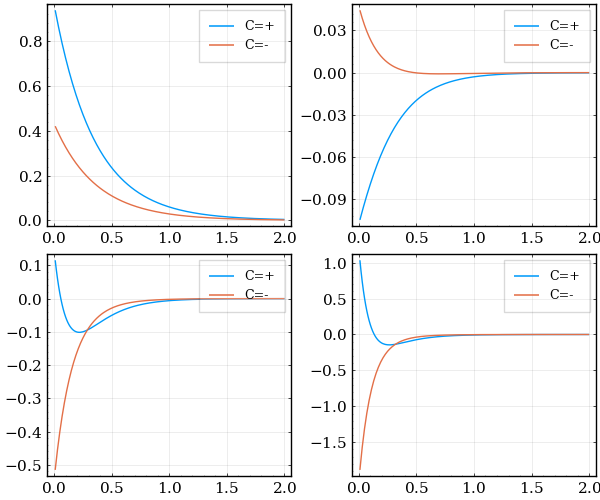

In [26]:
let rv = 0.0:0.01:2.0
    p1 = plot(rv, r -> potential_Xn(r, 0.5; C = 1), label = "C=+")
    plot!(rv, r -> potential_Xn(r, 0.5; C = -1), label = "C=-")
    p2 = plot(rv, r -> potential_Xn(r, 1.0; C = 1), label = "C=+")
    plot!(rv, r -> potential_Xn(r, 1.0; C = -1), label = "C=-")
    p3 = plot(rv, r -> potential_Xn(r, 1.5; C = 1), label = "C=+")
    plot!(rv, r -> potential_Xn(r, 1.5; C = -1), label = "C=-")
    p4 = plot(rv, r -> potential_Xn(r, 2.0; C = 1), label = "C=+")
    plot!(rv, r -> potential_Xn(r, 2.0; C = -1), label = "C=-")
    plot(p1, p2, p3, p4, layout = (2, 2), size = (600, 500))
end

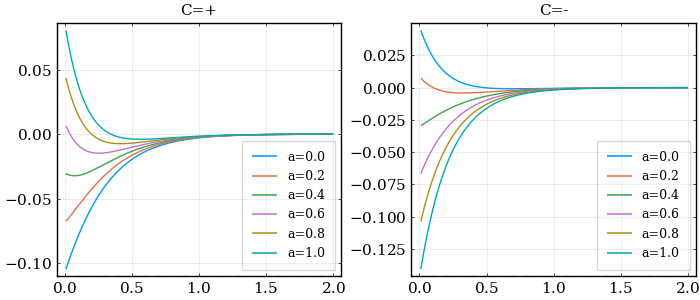

In [27]:
let rv = 0.0:0.01:2.0, av = 0.0:0.2:1.0, Λ = 1.0
    p1 = plot(title = "C=+", legend = :bottomright)
    for ai in av
        plot!(rv, r -> potential_Xn(r, Λ; C = 1, a = ai), label = "a=$ai")
    end
    p2 = plot(title = "C=-", legend = :bottomright)
    for ai in av
        plot!(rv, r -> potential_Xn(r, Λ; C = -1, a = ai), label = "a=$ai")
    end
    plot(p1, p2, layout = (1, 2), size = (700, 300))
end

## $[D^0\bar{D}^{*0}]\rightarrow [D^+D^{*-}]$

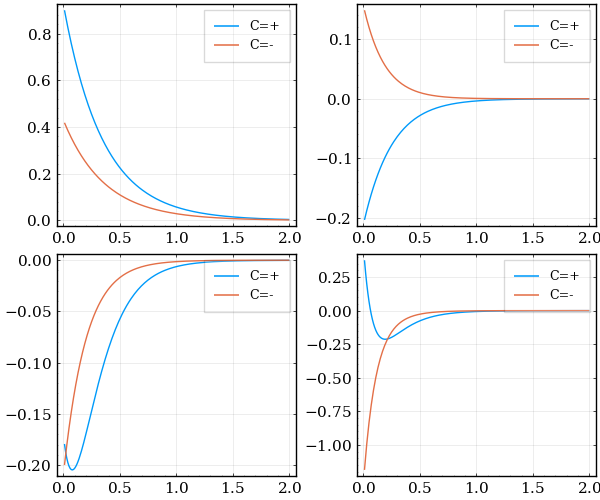

In [28]:
let rv = 0.0:0.01:2.0
    p1 = plot(rv, r -> potential_Xcross(r, 0.5; C = 1), label = "C=+")
    plot!(rv, r -> potential_Xcross(r, 0.5; C = -1), label = "C=-")
    p2 = plot(rv, r -> potential_Xcross(r, 1.0; C = 1), label = "C=+")
    plot!(rv, r -> potential_Xcross(r, 1.0; C = -1), label = "C=-")
    p3 = plot(rv, r -> potential_Xcross(r, 1.5; C = 1), label = "C=+")
    plot!(rv, r -> potential_Xcross(r, 1.5; C = -1), label = "C=-")
    p4 = plot(rv, r -> potential_Xcross(r, 2.0; C = 1), label = "C=+")
    plot!(rv, r -> potential_Xcross(r, 2.0; C = -1), label = "C=-")
    plot(p1, p2, p3, p4, layout = (2, 2), size = (600, 500))
end

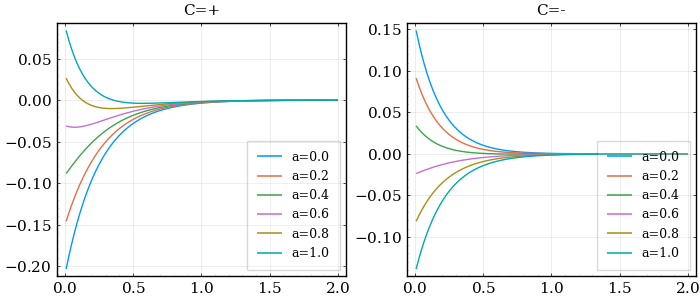

In [29]:
let rv = 0.0:0.01:2.0, av = 0.0:0.2:1.0, Λ = 1.0
    p1 = plot(title = "C=+", legend = :bottomright)
    for ai in av
        plot!(rv, r -> potential_Xcross(r, Λ; C = 1, a = ai), label = "a=$ai")
    end
    p2 = plot(title = "C=-", legend = :bottomright)
    for ai in av
        plot!(rv, r -> potential_Xcross(r, Λ; C = -1, a = ai), label = "a=$ai")
    end
    plot(p1, p2, layout = (1, 2), size = (700, 300))
end

## $[D^+D^{*-}]\rightarrow [D^+D^{*-}]$

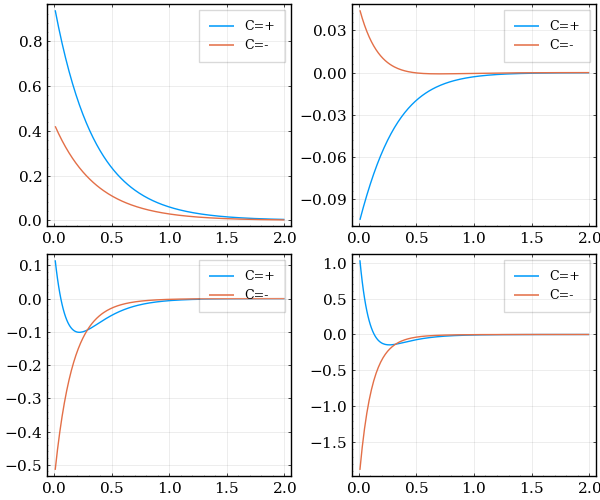

In [30]:
let rv = 0.0:0.01:2.0
    p1 = plot(rv, r -> potential_Xc(r, 0.5; C = 1), label = "C=+")
    plot!(rv, r -> potential_Xc(r, 0.5; C = -1), label = "C=-")
    p2 = plot(rv, r -> potential_Xc(r, 1.0; C = 1), label = "C=+")
    plot!(rv, r -> potential_Xc(r, 1.0; C = -1), label = "C=-")
    p3 = plot(rv, r -> potential_Xc(r, 1.5; C = 1), label = "C=+")
    plot!(rv, r -> potential_Xc(r, 1.5; C = -1), label = "C=-")
    p4 = plot(rv, r -> potential_Xc(r, 2.0; C = 1), label = "C=+")
    plot!(rv, r -> potential_Xc(r, 2.0; C = -1), label = "C=-")
    plot(p1, p2, p3, p4, layout = (2, 2), size = (600, 500))
end

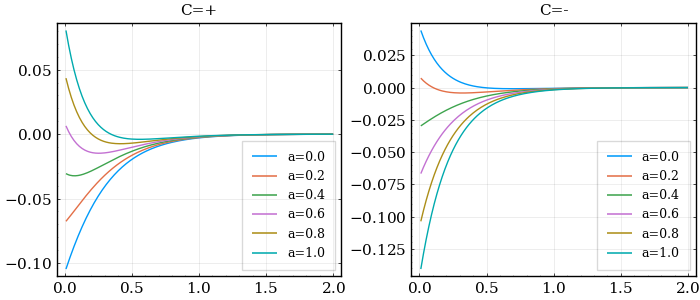

In [31]:
let rv = 0.0:0.01:2.0, av = 0.0:0.2:1.0, Λ = 1.0
    p1 = plot(title = "C=+", legend = :bottomright)
    for ai in av
        plot!(rv, r -> potential_Xc(r, Λ; C = 1, a = ai), label = "a=$ai")
    end
    p2 = plot(title = "C=-", legend = :bottomright)
    for ai in av
        plot!(rv, r -> potential_Xc(r, Λ; C = -1, a = ai), label = "a=$ai")
    end
    plot(p1, p2, layout = (1, 2), size = (700, 300))
end

## under isospin basis

### I=0

In [32]:
function potential_X_detailed(r, Λ; C = 1, a = 0.0, st = [1, 0], particle = "π") # potential for heavy charm-anticharm hadronical molecules
    res = 0.0
    if particle == "π"
        res = potential_Xn(r, Λ; C = C, a = a, st = st, full = false, particle = ["π"]) + 2 * potential_Xcross(r, Λ; C = C, a = a, st = st, full = false, particle = ["π"]) + potential_Xc(r, Λ; C = C, a = a, st = st, full = false, particle = ["π"])
    elseif particle == "η"
        res = potential_Xn(r, Λ; C = C, a = a, st = st, full = false, particle = ["η"]) + 2 * potential_Xcross(r, Λ; C = C, a = a, st = st, full = false, particle = ["η"]) + potential_Xc(r, Λ; C = C, a = a, st = st, full = false, particle = ["η"])
    elseif particle == "ρ"
        res = potential_Xn(r, Λ; C = C, a = a, st = st, full = false, particle = ["ρ"]) + 2 * potential_Xcross(r, Λ; C = C, a = a, st = st, full = false, particle = ["ρ"]) + potential_Xc(r, Λ; C = C, a = a, st = st, full = false, particle = ["ρ"])
    elseif particle == "ω"
        res = potential_Xn(r, Λ; C = C, a = a, st = st, full = false, particle = ["ω"]) + 2 * potential_Xcross(r, Λ; C = C, a = a, st = st, full = false, particle = ["ω"]) + potential_Xc(r, Λ; C = C, a = a, st = st, full = false, particle = ["ω"])
    elseif particle == "σ"
        res = potential_Xn(r, Λ; C = C, a = a, st = st, full = false, particle = ["σ"]) + 2 * potential_Xcross(r, Λ; C = C, a = a, st = st, full = false, particle = ["σ"]) + potential_Xc(r, Λ; C = C, a = a, st = st, full = false, particle = ["σ"])
    end
    return res / 2.0
end

potential_X_detailed (generic function with 1 method)

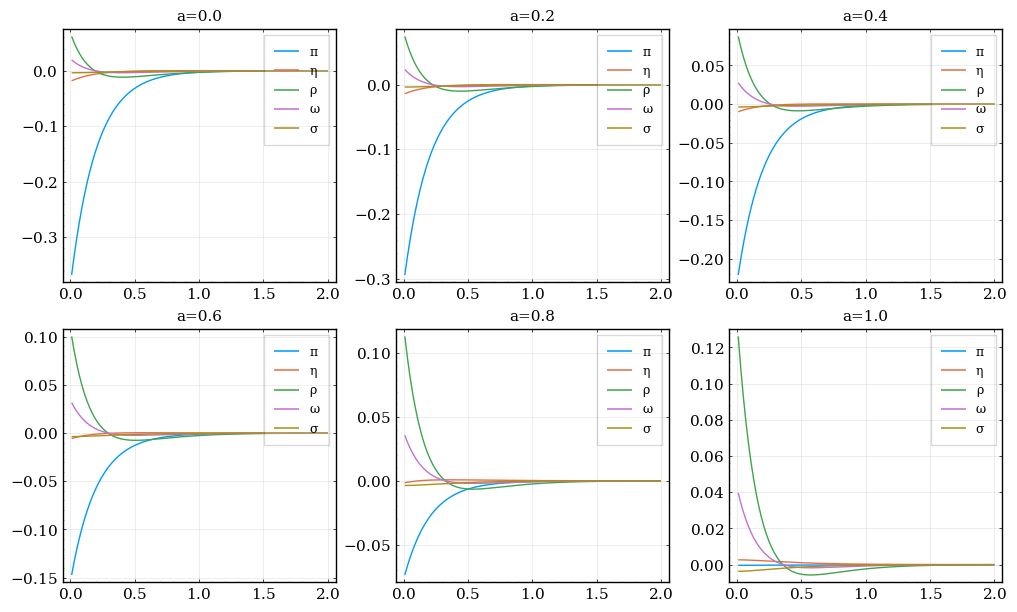

"/Users/linqiu/Nutstore Files/Nutstore/Projects/gitrepos/Tcc/SHE/images/potentials/potential_X_detailed.png"

In [33]:
let rv = 0.0:0.01:2.0, Λ = 1.0, st = [1, 0], av = collect(0.0:0.2:1.0) #potential with respect to contact parameter a
    plt = Vector{Any}(undef, 6)
    for i in 1:6
        plt[i] = plot(title = "a=$(av[i])")
        plot!(rv, r -> potential_X_detailed(r, Λ; a = av[i], st = st, particle = "π"), label = "π")
        plot!(rv, r -> potential_X_detailed(r, Λ; a = av[i], st = st, particle = "η"), label = "η")
        plot!(rv, r -> potential_X_detailed(r, Λ; a = av[i], st = st, particle = "ρ"), label = "ρ")
        plot!(rv, r -> potential_X_detailed(r, Λ; a = av[i], st = st, particle = "ω"), label = "ω")
        plot!(rv, r -> potential_X_detailed(r, Λ; a = av[i], st = st, particle = "σ"), label = "σ")
    end
    plot(plt..., layout = (2, 3), size = (1000, 600))
    savefig("./images/potentials/potential_X_detailed.png")
end

In [34]:
function potential_isospin_X(r, Λ; C = 1, a = 0.0, st = [1, 0], particle = "obe")
    res = 0.0
    if particle == "obe"
        res = potential_Xn(r, Λ; C = C, a = a, st = st) + 2 * potential_Xcross(r, Λ; C = C, a = a, st = st) + potential_Xc(r, Λ; C = C, a = a, st = st)
    elseif particle == "ope"
        res = potential_Xn(r, Λ; C = C, a = a, st = st, full = false, particle = ["π"]) + 2 * potential_Xcross(r, Λ; C = C, a = a, st = st, full = false, particle = ["π"]) + potential_Xc(r, Λ; C = C, a = a, st = st, full = false, particle = ["π"])
    else
        res = potential_Xn(r, Λ; C = C, a = a, st = st, full = false, particle = ["η", "ρ", "ω", "σ"]) + 2 * potential_Xcross(r, Λ; C = C, a = a, st = st, full = false, particle = ["η", "ρ", "ω", "σ"]) + potential_Xc(r, Λ; C = C, a = a, st = st, full = false, particle = ["η", "ρ", "ω", "σ"])
    end
    return res / 2.0
end

potential_isospin_X (generic function with 1 method)

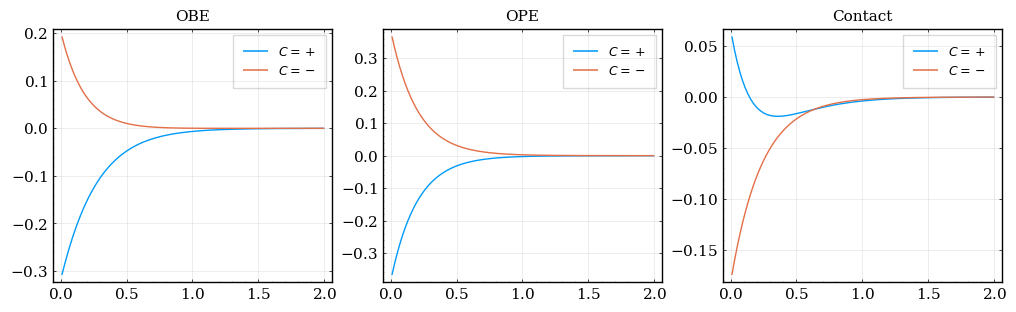

"/Users/linqiu/Nutstore Files/Nutstore/Projects/gitrepos/Tcc/SHE/images/potentials/potential_X_partners_bpc.png"

In [35]:
let rv = 0.0:0.01:2.0, Λ = 1.0
    p1 = plot(title = "OBE")
    plot!(rv, r -> potential_isospin_X(r, Λ; C = 1, a = 0.0, st = [1, 0], particle = "obe"), label = L"C=+")
    plot!(rv, r -> potential_isospin_X(r, Λ; C = -1, a = 0.0, st = [1, 0], particle = "obe"), label = L"C=-")
    p2 = plot(title = "OPE")
    plot!(rv, r -> potential_isospin_X(r, Λ; C = 1, a = 0.0, st = [1, 0], particle = "ope"), label = L"C=+")
    plot!(rv, r -> potential_isospin_X(r, Λ; C = -1, a = 0.0, st = [1, 0], particle = "ope"), label = L"C=-")
    p3 = plot(title = "Contact")
    plot!(rv, r -> potential_isospin_X(r, Λ; C = 1, a = 0.0, st = [1, 0], particle = "contact"), label = L"C=+")
    plot!(rv, r -> potential_isospin_X(r, Λ; C = -1, a = 0.0, st = [1, 0], particle = "contact"), label = L"C=-")

    plot(p1, p2, p3, layout = (1, 3), size = (1000, 300))
    savefig("./images/potentials/potential_X_partners_bpc.png")
end

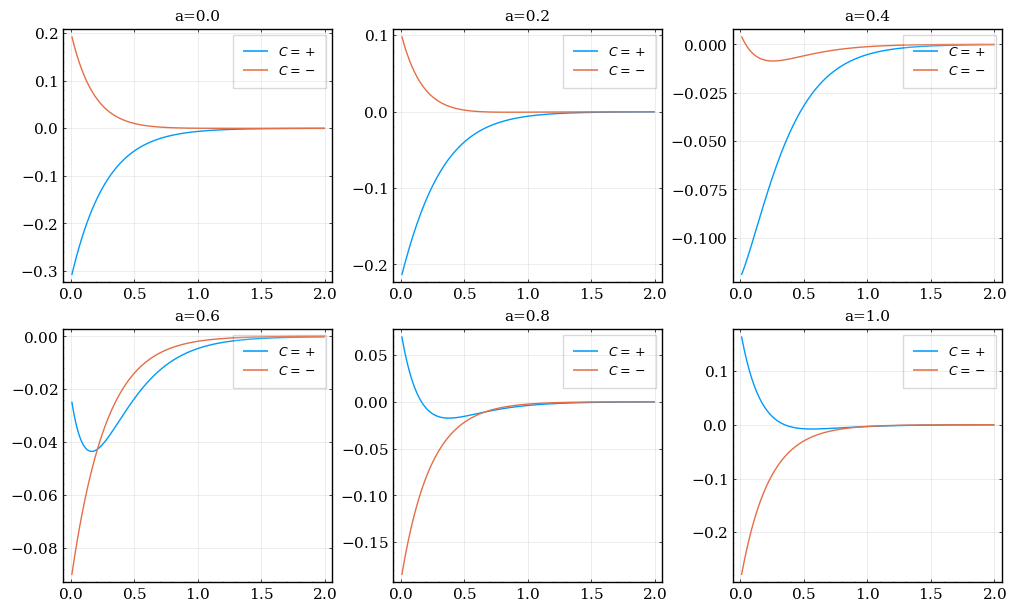

"/Users/linqiu/Nutstore Files/Nutstore/Projects/gitrepos/Tcc/SHE/images/potentials/potential_X_partners_ss.png"

In [36]:
# S->S
let rv = 0.0:0.01:2.0, Λ = 1.0, av = collect(0.0:0.2:1.0)
    plt = Vector{Any}(undef, 6)
    for i in 1:1:6
        plt[i] = plot(title = "a=$(av[i])")
        plot!(rv, r -> potential_isospin_X(r, Λ; C = 1, a = av[i], st = [1, 0], particle = "obe"), label = L"C=+")
        plot!(rv, r -> potential_isospin_X(r, Λ; C = -1, a = av[i], st = [1, 0], particle = "obe"), label = L"C=-")
    end
    plot(plt..., layout = (2, 3), size = (1000, 600))
    savefig("./images/potentials/potential_X_partners_ss.png")
end

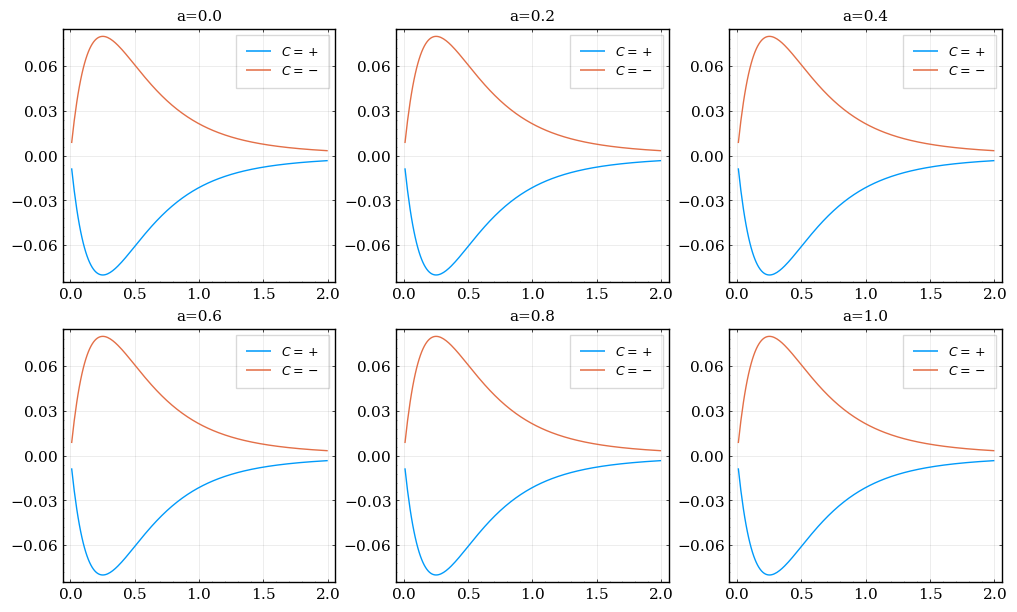

"/Users/linqiu/Nutstore Files/Nutstore/Projects/gitrepos/Tcc/SHE/images/potentials/potential_X_partners_sd.png"

In [37]:
# S->D
let rv = 0.0:0.01:2.0, Λ = 1.0, av = collect(0.0:0.2:1.0), st = [0, -√2]
    plt = Vector{Any}(undef, 6)
    for i in 1:1:6
        plt[i] = plot(title = "a=$(av[i])")
        plot!(rv, r -> potential_isospin_X(r, Λ; C = 1, a = av[i], st = st, particle = "obe"), label = L"C=+")
        plot!(rv, r -> potential_isospin_X(r, Λ; C = -1, a = av[i], st = st, particle = "obe"), label = L"C=-")
    end
    plot(plt..., layout = (2, 3), size = (1000, 600))
    savefig("./images/potentials/potential_X_partners_sd.png")
end

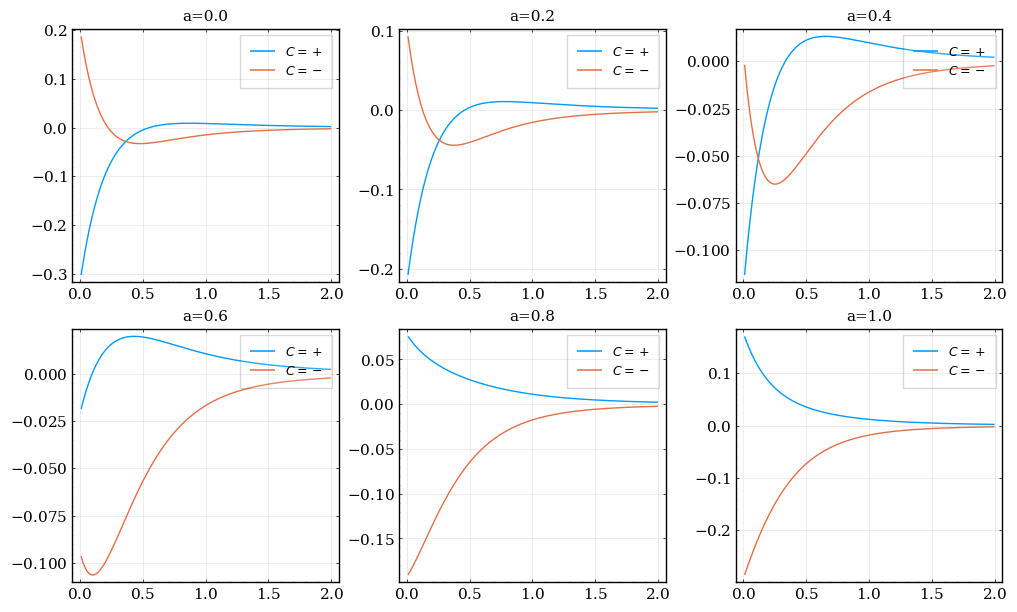

"/Users/linqiu/Nutstore Files/Nutstore/Projects/gitrepos/Tcc/SHE/images/potentials/potential_X_partners_dd.png"

In [38]:
# D->D
let rv = 0.0:0.01:2.0, Λ = 1.0, av = collect(0.0:0.2:1.0), st = [1, 1]
    plt = Vector{Any}(undef, 6)
    for i in 1:1:6
        plt[i] = plot(title = "a=$(av[i])")
        plot!(rv, r -> potential_isospin_X(r, Λ; C = 1, a = av[i], st = st, particle = "obe"), label = L"C=+")
        plot!(rv, r -> potential_isospin_X(r, Λ; C = -1, a = av[i], st = st, particle = "obe"), label = L"C=-")
    end
    plot(plt..., layout = (2, 3), size = (1000, 600))
    savefig("./images/potentials/potential_X_partners_dd.png")
end

### I=1

In [39]:
function potential_Zc_detailed(r, Λ; C = 1, a = 0.0, st = [1, 0], particle = "π")
    res = 0.0
    if particle == "π"
        res = potential_Xn(r, Λ; C = C, a = a, st = st, full = false, particle = ["π"]) - 2 * potential_Xcross(r, Λ; C = C, a = a, st = st, full = false, particle = ["π"]) + potential_Xc(r, Λ; C = C, a = a, st = st, full = false, particle = ["π"])
    elseif particle == "η"
        res = potential_Xn(r, Λ; C = C, a = a, st = st, full = false, particle = ["η"]) - 2 * potential_Xcross(r, Λ; C = C, a = a, st = st, full = false, particle = ["η"]) + potential_Xc(r, Λ; C = C, a = a, st = st, full = false, particle = ["η"])
    elseif particle == "ρ"
        res = potential_Xn(r, Λ; C = C, a = a, st = st, full = false, particle = ["ρ"]) - 2 * potential_Xcross(r, Λ; C = C, a = a, st = st, full = false, particle = ["ρ"]) + potential_Xc(r, Λ; C = C, a = a, st = st, full = false, particle = ["ρ"])
    elseif particle == "ω"
        res = potential_Xn(r, Λ; C = C, a = a, st = st, full = false, particle = ["ω"]) - 2 * potential_Xcross(r, Λ; C = C, a = a, st = st, full = false, particle = ["ω"]) + potential_Xc(r, Λ; C = C, a = a, st = st, full = false, particle = ["ω"])
    elseif particle == "σ"
        res = potential_Xn(r, Λ; C = C, a = a, st = st, full = false, particle = ["σ"]) - 2 * potential_Xcross(r, Λ; C = C, a = a, st = st, full = false, particle = ["σ"]) + potential_Xc(r, Λ; C = C, a = a, st = st, full = false, particle = ["σ"])
    end
    return res / 2.0
end

potential_Zc_detailed (generic function with 1 method)

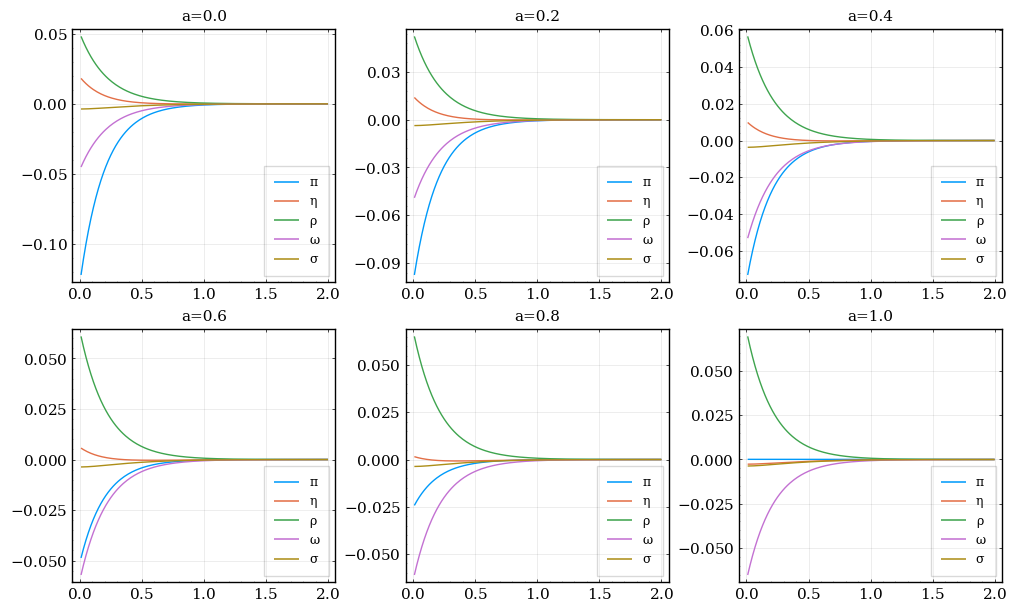

"/Users/linqiu/Nutstore Files/Nutstore/Projects/gitrepos/Tcc/SHE/images/potentials/potential_Zc_detailed.png"

In [40]:
let rv = 0.0:0.01:2.0, Λ = 1.0, st = [1, 0], av = collect(0.0:0.2:1.0)
    plt = Vector{Any}(undef, 6)
    for i in 1:6
        plt[i] = plot(title = "a=$(av[i])", legend = :bottomright)
        plot!(rv, r -> potential_Zc_detailed(r, Λ; C = -1, a = av[i], st = st, particle = "π"), label = "π")
        plot!(rv, r -> potential_Zc_detailed(r, Λ; C = -1, a = av[i], st = st, particle = "η"), label = "η")
        plot!(rv, r -> potential_Zc_detailed(r, Λ; C = -1, a = av[i], st = st, particle = "ρ"), label = "ρ")
        plot!(rv, r -> potential_Zc_detailed(r, Λ; C = -1, a = av[i], st = st, particle = "ω"), label = "ω")
        plot!(rv, r -> potential_Zc_detailed(r, Λ; C = -1, a = av[i], st = st, particle = "σ"), label = "σ")
    end
    plot(plt..., layout = (2, 3), size = (1000, 600))
    savefig("./images/potentials/potential_Zc_detailed.png")
end

In [41]:
function potential_isospin_Zc(r, Λ; C = 1, a = 0.0, st = [1, 0], particle = "obe")
    res = 0.0
    if particle == "obe"
        res = potential_Xn(r, Λ; C = C, a = a, st = st) - 2 * potential_Xcross(r, Λ; C = C, a = a, st = st) + potential_Xc(r, Λ; C = C, a = a, st = st)
    elseif particle == "ope"
        res = potential_Xn(r, Λ; C = C, a = a, st = st, full = false, particle = ["π"]) - 2 * potential_Xcross(r, Λ; C = C, a = a, st = st, full = false, particle = ["π"]) + potential_Xc(r, Λ; C = C, a = a, st = st, full = false, particle = ["π"])
    else
        res = potential_Xn(r, Λ; C = C, a = a, st = st, full = false, particle = ["η", "ρ", "ω", "σ"]) - 2 * potential_Xcross(r, Λ; C = C, a = a, st = st, full = false, particle = ["η", "ρ", "ω", "σ"]) + potential_Xc(r, Λ; C = C, a = a, st = st, full = false, particle = ["η", "ρ", "ω", "σ"])
    end
    return res / 2.0
end

potential_isospin_Zc (generic function with 1 method)

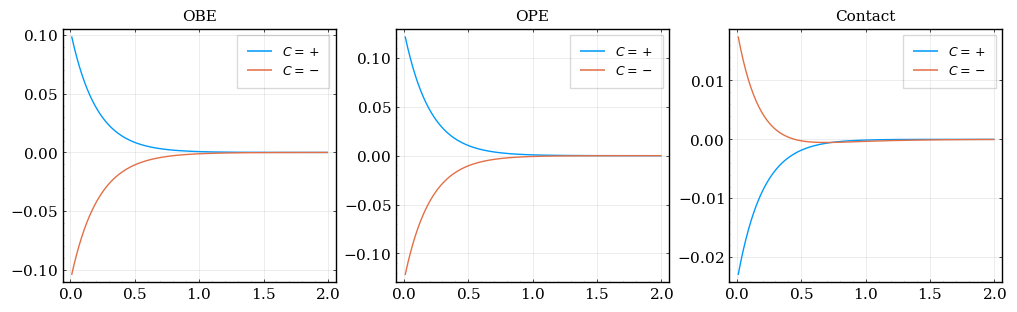

"/Users/linqiu/Nutstore Files/Nutstore/Projects/gitrepos/Tcc/SHE/images/potentials/potential_Zc_partners_bpc.png"

In [42]:
let rv = 0.0:0.01:2.0, Λ = 1.0
    p1 = plot(title = "OBE")
    plot!(rv, r -> potential_isospin_Zc(r, Λ; C = 1, a = 0.0, st = [1, 0], particle = "obe"), label = L"C=+")
    plot!(rv, r -> potential_isospin_Zc(r, Λ; C = -1, a = 0.0, st = [1, 0], particle = "obe"), label = L"C=-")
    p2 = plot(title = "OPE")
    plot!(rv, r -> potential_isospin_Zc(r, Λ; C = 1, a = 0.0, st = [1, 0], particle = "ope"), label = L"C=+")
    plot!(rv, r -> potential_isospin_Zc(r, Λ; C = -1, a = 0.0, st = [1, 0], particle = "ope"), label = L"C=-")
    p3 = plot(title = "Contact")
    plot!(rv, r -> potential_isospin_Zc(r, Λ; C = 1, a = 0.0, st = [1, 0], particle = "contact"), label = L"C=+")
    plot!(rv, r -> potential_isospin_Zc(r, Λ; C = -1, a = 0.0, st = [1, 0], particle = "contact"), label = L"C=-")

    plot(p1, p2, p3, layout = (1, 3), size = (1000, 300))
    savefig("./images/potentials/potential_Zc_partners_bpc.png")
end

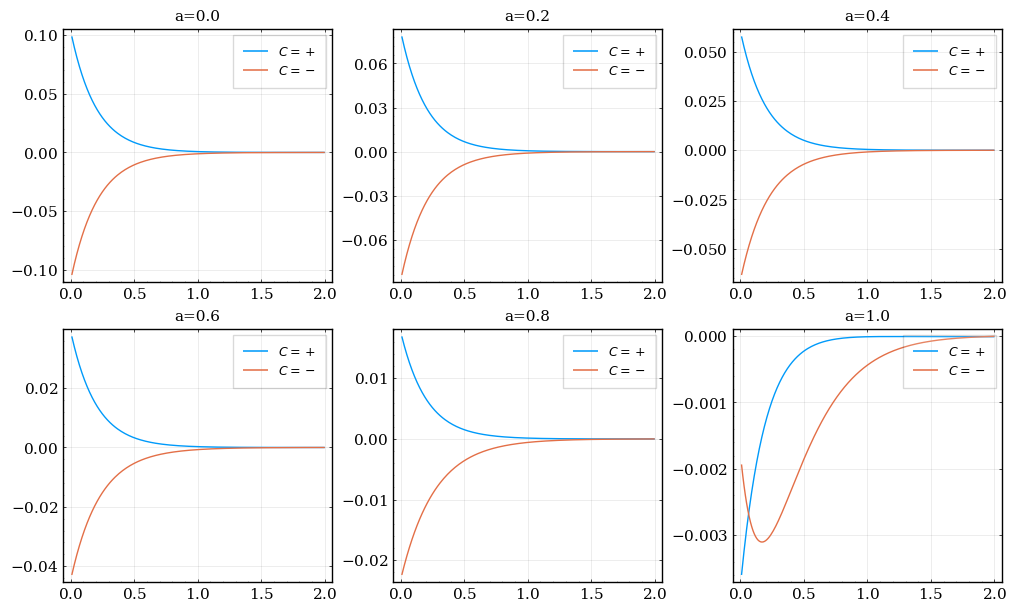

"/Users/linqiu/Nutstore Files/Nutstore/Projects/gitrepos/Tcc/SHE/images/potentials/potential_Zc_partners_ss.png"

In [43]:
# S->S
let rv = 0.0:0.01:2.0, Λ = 1.0, av = collect(0.0:0.2:1.0)
    plt = Vector{Any}(undef, 6)
    for i in 1:1:6
        plt[i] = plot(title = "a=$(av[i])")
        plot!(rv, r -> potential_isospin_Zc(r, Λ; C = 1, a = av[i], st = [1, 0], particle = "obe"), label = L"C=+")
        plot!(rv, r -> potential_isospin_Zc(r, Λ; C = -1, a = av[i], st = [1, 0], particle = "obe"), label = L"C=-")
    end
    plot(plt..., layout = (2, 3), size = (1000, 600))
    savefig("./images/potentials/potential_Zc_partners_ss.png")
end

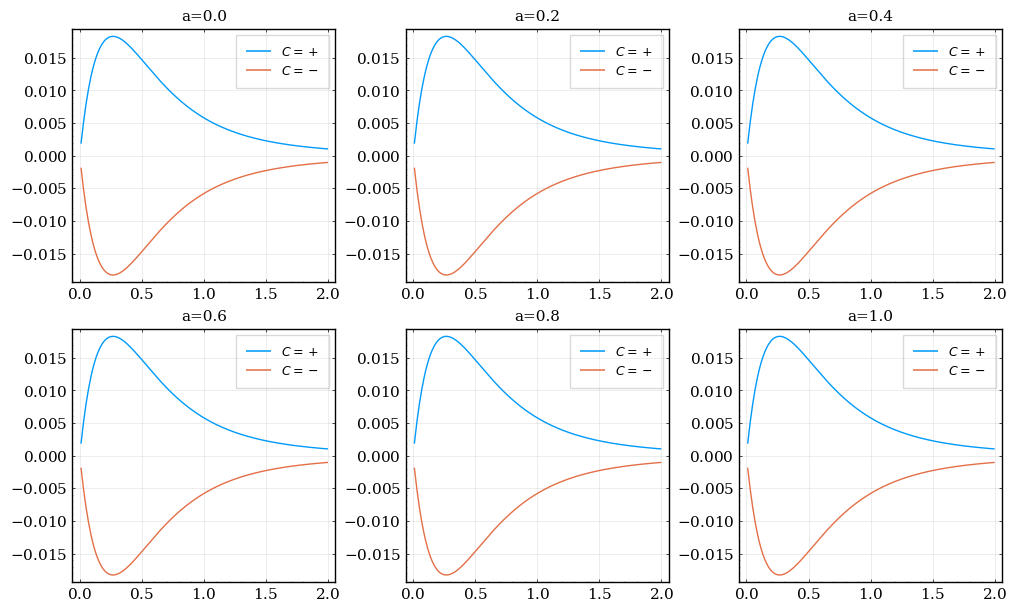

"/Users/linqiu/Nutstore Files/Nutstore/Projects/gitrepos/Tcc/SHE/images/potentials/potential_Zc_partners_sd.png"

In [44]:
# S->D
let rv = 0.0:0.01:2.0, Λ = 1.0, av = collect(0.0:0.2:1.0), st = [0, -√2]
    plt = Vector{Any}(undef, 6)
    for i in 1:1:6
        plt[i] = plot(title = "a=$(av[i])")
        plot!(rv, r -> potential_isospin_Zc(r, Λ; C = 1, a = av[i], st = st, particle = "obe"), label = L"C=+")
        plot!(rv, r -> potential_isospin_Zc(r, Λ; C = -1, a = av[i], st = st, particle = "obe"), label = L"C=-")
    end
    plot(plt..., layout = (2, 3), size = (1000, 600))
    savefig("./images/potentials/potential_Zc_partners_sd.png")
end

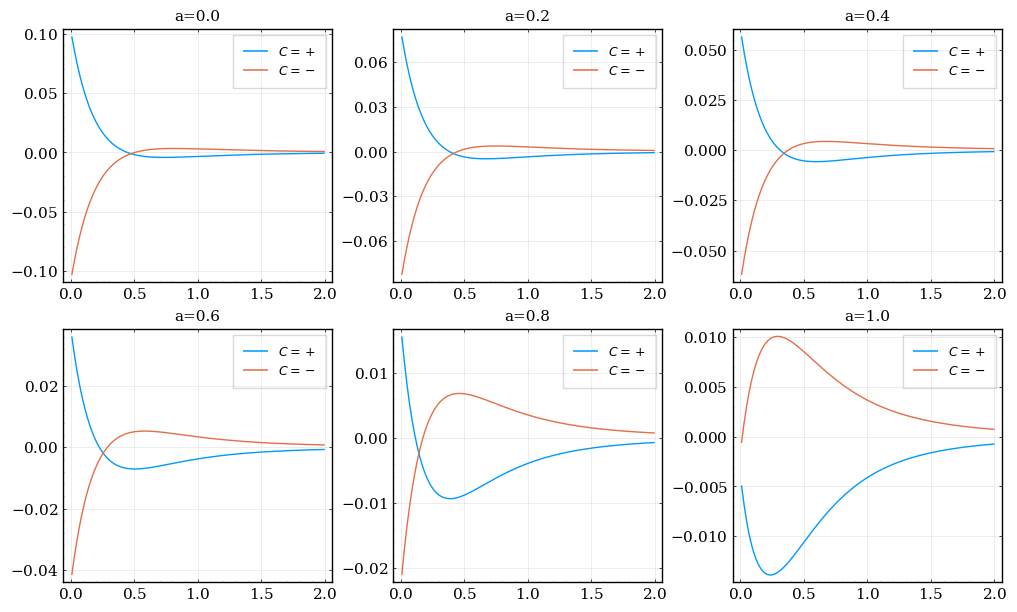

"/Users/linqiu/Nutstore Files/Nutstore/Projects/gitrepos/Tcc/SHE/images/potentials/potential_Zc_partners_dd.png"

In [45]:
# D->D
let rv = 0.0:0.01:2.0, Λ = 1.0, av = collect(0.0:0.2:1.0), st = [1, 1]
    plt = Vector{Any}(undef, 6)
    for i in 1:1:6
        plt[i] = plot(title = "a=$(av[i])")
        plot!(rv, r -> potential_isospin_Zc(r, Λ; C = 1, a = av[i], st = st, particle = "obe"), label = L"C=+")
        plot!(rv, r -> potential_isospin_Zc(r, Λ; C = -1, a = av[i], st = st, particle = "obe"), label = L"C=-")
    end
    plot(plt..., layout = (2, 3), size = (1000, 600))
    savefig("./images/potentials/potential_Zc_partners_dd.png")
end

# Solution of schrodinger equation(Fully)
**Gaussian-expansion-method" to solve coupled-channel Schrodinger equation: see https://doi.org/10.1016/S0146-6410(03)90015-9**

In [46]:
nmax = 60;
νnt = [νnf(i, 0.01, 40.0, nmax) for i = 1:1:nmax];

In [47]:
global xxx;
global www;

In [48]:
function makegauss(n)
    global xxx, www = gauss(n, 0, 1)
end

makegauss (generic function with 1 method)

In [49]:
makegauss(128);

## DD

In [50]:
NMat_DD=zeros(Float64, nmax,  nmax);

In [51]:
for i in 1:1:nmax
    for j in 1:1:nmax
        NMat_DD[i, j] = NMatrix_gem(νnt[i], νnt[j], 0)
    end
end

In [52]:
TMat_DD=zeros(Float64, nmax,  nmax);

In [53]:
for i in 1:1:nmax
    for j in 1:1:nmax
        TMat_DD[i, j] = TMatrix_gem(νnt[i], νnt[j], 0, μf(mDn, mDc), hbarc)
    end
end

In [54]:
VMat_DD = zeros(Float64,  nmax,  nmax);

In [55]:
function VMat_DD!(Λ; I = 0)
    for i in 1:1:nmax
        for j in 1:1:nmax
            VMat_DD[i, j] = VMatrix_gem(r -> potential_DD(r, Λ; I = I), νnt[i], νnt[j], 0)
        end
    end
end

VMat_DD! (generic function with 1 method)

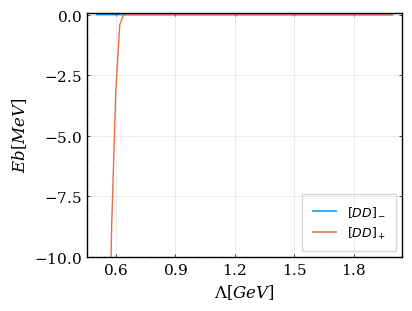

"/Users/linqiu/Nutstore Files/Nutstore/Projects/gitrepos/Tcc/SHE/images/she/eb_dep_dd.png"

In [57]:
let
    function tmpf(Λ; I = 0)
        VMat_DD!(Λ; I = I)
        return eigvals(TMat_DD + VMat_DD , NMat_DD)[1]
    end

    plot(xlabel = L"\Lambda[GeV]",ylabel=L"Eb[MeV]",ylim=[-10,0.1],legend=:bottomright)
    # plot!(0.5:0.02:2.0,x -> real(tmpf(x; I = 0))*1e3, label = L"[DD]_-")
    # plot!(0.5:0.02:2.0,x -> real(tmpf(x; I = 1))*1e3, label = L"[DD]_+")
    plot!(0.5:0.02:2.0,x -> tmpf(x; I = 0)*1e3, label = L"[DD]_-")
    plot!(0.5:0.02:2.0,x -> tmpf(x; I = 1)*1e3, label = L"[DD]_+")
    savefig("./images/she/eb_dep_dd.png")
end

In [58]:
let
    function tmpf(Λ; I = 0)
        VMat_DD!(Λ; I = I)
        return eigvals(TMat_DD + VMat_DD , NMat_DD)
    end

    tmpf(0.7;I=1)
end

60-element Vector{Float64}:
    1.444476266109968e-5
    5.875753303114438e-5
    0.000135978737310132
    0.00025152472238142284
    0.00041371218656566293
    0.0006345043310907933
    0.0009305105494631606
    0.001324310198486635
    0.0018462114660714377
    0.002536605672413522
    0.0034491278464908676
    0.004655447737123825
    0.006249590246171553
    ⋮
  167.97910135585616
  223.11656673775562
  296.61272318960994
  394.799157958336
  526.3777410576661
  703.4755243975175
  943.3336653149875
 1271.1938587850073
 1725.699388158211
 2370.421961903572
 3324.110498056277
 4877.367807851433

## $T_{cc}^+$

In [59]:
ΔT = mDc + mDsn - mDn - mDsc

0.0013599999999995838

In [60]:
ΔMatT = zeros(Float64, 4 * nmax, 4 * nmax);

In [61]:
for i in 1:1:nmax
    for j in 1:1:nmax
        ΔMatT[i+2*nmax, j+2*nmax] = ΔT * NMatrix_gem(νnt[i], νnt[j], 0)
        ΔMatT[i+3*nmax, j+3*nmax] = ΔT * NMatrix_gem(νnt[i], νnt[j], 2)
    end
end

In [62]:
NMatT = zeros(Float64, 4 * nmax, 4 * nmax);

In [63]:
for i in 1:1:nmax
    for j in 1:1:nmax
        NMatT[i, j] = NMatrix_gem(νnt[i], νnt[j], 0)
        NMatT[i+nmax, j+nmax] = NMatrix_gem(νnt[i], νnt[j], 2)
        NMatT[i+2*nmax, j+2*nmax] = NMatrix_gem(νnt[i], νnt[j], 0)
        NMatT[i+3*nmax, j+3*nmax] = NMatrix_gem(νnt[i], νnt[j], 2)
    end
end

In [64]:
TMatT = zeros(Float64, 4 * nmax, 4 * nmax);

In [65]:
for i in 1:1:nmax
    for j in 1:1:nmax
        TMatT[i, j] = TMatrix_gem(νnt[i], νnt[j], 0, μf(mDn, mDsc), hbarc)
        TMatT[i+nmax, j+nmax] = TMatrix_gem(νnt[i], νnt[j], 2, μf(mDn, mDsc), hbarc)
        TMatT[i+2*nmax, j+2*nmax] = TMatrix_gem(νnt[i], νnt[j], 0, μf(mDc, mDsn), hbarc)
        TMatT[i+3*nmax, j+3*nmax] = TMatrix_gem(νnt[i], νnt[j], 2, μf(mDc, mDsn), hbarc)
    end
end

In [66]:
VMatT = zeros(Float64, 4 * nmax, 4 * nmax);

In [67]:
function VMatT!(Λ; I = 0, a = 0.0)
    for i in 1:1:nmax
        for j in 1:1:nmax
            VMatT[i, j] = VMatrix_gem(r -> potential_DnDsc(r, Λ; I = I, a = a, st = [1.0, 0.0]), νnt[i], νnt[j], 0)
            VMatT[i, j+nmax] = VMatrix_gem(r -> potential_DnDsc(r, Λ; I = I, a = a, st = [0, -sqrt(2)]), νnt[i], νnt[j], 0)
            VMatT[i+nmax, j] = VMatrix_gem(r -> potential_DnDsc(r, Λ; I = I, a = a, st = [0, -sqrt(2)]), νnt[i], νnt[j], 2)
            VMatT[i+nmax, j+nmax] = VMatrix_gem(r -> potential_DnDsc(r, Λ; I = I, a = a, st = [1.0, 1.0]), νnt[i], νnt[j], 2)
            VMatT[i, j+2*nmax] = VMatrix_gem(r -> potential_DDscross(r, Λ; I = I, a = a, st = [1.0, 0.0]), νnt[i], νnt[j], 0)
            VMatT[i, j+3*nmax] = VMatrix_gem(r -> potential_DDscross(r, Λ; I = I, a = a, st = [0, -sqrt(2)]), νnt[i], νnt[j], 0)
            VMatT[i+nmax, j+2*nmax] = VMatrix_gem(r -> potential_DDscross(r, Λ; I = I, a = a, st = [0, -sqrt(2)]), νnt[i], νnt[j], 2)
            VMatT[i+nmax, j+3*nmax] = VMatrix_gem(r -> potential_DDscross(r, Λ; I = I, a = a, st = [1.0, 1.0]), νnt[i], νnt[j], 2)
            VMatT[i+2*nmax, j] = VMatrix_gem(r -> potential_DDscross(r, Λ; I = I, a = a, st = [1.0, 0.0]), νnt[i], νnt[j], 0)
            VMatT[i+2*nmax, j+nmax] = VMatrix_gem(r -> potential_DDscross(r, Λ; I = I, a = a, st = [0, -sqrt(2)]), νnt[i], νnt[j], 0)
            VMatT[i+3*nmax, j] = VMatrix_gem(r -> potential_DDscross(r, Λ; I = I, a = a, st = [0, -sqrt(2)]), νnt[i], νnt[j], 2)
            VMatT[i+3*nmax, j+nmax] = VMatrix_gem(r -> potential_DDscross(r, Λ; I = I, a = a, st = [1.0, 1.0]), νnt[i], νnt[j], 2)
            VMatT[i+2*nmax, j+2*nmax] = VMatrix_gem(r -> potential_DcDsn(r, Λ; I = I, a = a, st = [1.0, 0.0]), νnt[i], νnt[j], 0)
            VMatT[i+2*nmax, j+3*nmax] = VMatrix_gem(r -> potential_DcDsn(r, Λ; I = I, a = a, st = [0, -sqrt(2)]), νnt[i], νnt[j], 0)
            VMatT[i+3*nmax, j+2*nmax] = VMatrix_gem(r -> potential_DcDsn(r, Λ; I = I, a = a, st = [0, -sqrt(2)]), νnt[i], νnt[j], 2)
            VMatT[i+3*nmax, j+3*nmax] = VMatrix_gem(r -> potential_DcDsn(r, Λ; I = I, a = a, st = [1.0, 1.0]), νnt[i], νnt[j], 2)
        end
    end
end

VMatT! (generic function with 1 method)

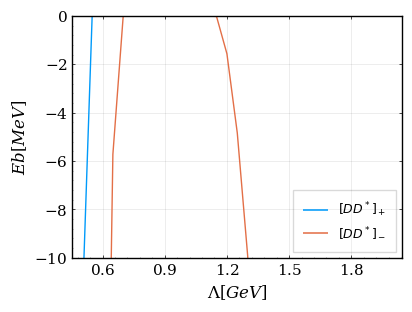

"/Users/linqiu/Nutstore Files/Nutstore/Projects/gitrepos/Tcc/SHE/images/she/eb_dep_tcc.png"

In [68]:
let #cutoff dependence of binding energy for I=0/1 double-charm HM
    function tmpf(Λ; I = 0, a = 0.0)
        VMatT!(Λ; I = I, a = a)
        return eigvals(TMatT + VMatT + ΔMatT, NMatT)[1]
    end

    plot(xlabel = L"\Lambda[GeV]",ylabel=L"Eb[MeV]", ylims = [-10, 0.0],legend=:bottomright)
    plot!(0.5:0.05:2.0,x -> real(tmpf(x; I = 0))*1e3, label = L"[DD^*]_+")
    plot!(0.5:0.05:2.0,x -> real(tmpf(x; I = 1))*1e3, label = L"[DD^*]_-")
    savefig("./images/she/eb_dep_tcc.png")
end

[1.1645749370536849, 1.1864905804104637, 1.2083579547887382, 1.2301875019028152, 1.2519892738018825, 1.2737729616039846, 1.2955479247171742, 1.3173232203216756, 1.3391076317784467, 1.3609096961744025, 1.3827377300876835]

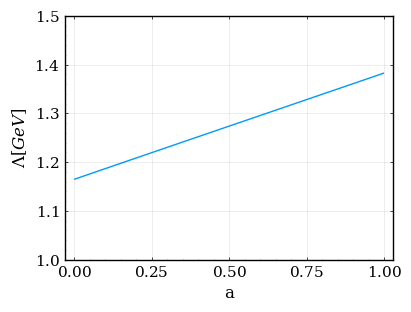

"/Users/linqiu/Nutstore Files/Nutstore/Projects/gitrepos/Tcc/SHE/images/she/lam_a_dep_tcc.png"

In [69]:
let # cutoff-a dependence to keep the same BW Tcc mass
    function tmpf(Λ; I = 0, a = 0.0)
        VMatT!(Λ; I = I, a = a)
        return eigvals(TMatT + VMatT + ΔMatT, NMatT)[1]
    end

    function tmpf1(a)
        res = 0.0
        try
            res = find_zero(x -> (real(tmpf(x; I = 1, a = a)) - (-0.273e-3)), (1.0, 1.5))
        catch
            res = NaN
        end
        return res
    end
    av = collect(0.0:0.1:1.0)
    Λv = tmpf1.(av)
    print(Λv)
    plot(av, Λv, xlabel = "a", ylabel = L"\Lambda[GeV]", ylims = [1.0, 1.5], label = false)
    savefig("./images/she/lam_a_dep_tcc.png")
end

In [77]:
let
    function tmpf(Λ; I = 0, a = 0.0)
        VMatT!(Λ; I = I, a = a)
        return eigvals(TMatT + VMatT + ΔMatT, NMatT)[1]
    end

    function tmpf1(a)
        res = 0.0
        try
            res = find_zero(x -> (real(tmpf(x; I = 1, a = a)) - (-0.273e-3)), (1.0, 1.5))
        catch
            res = NaN
        end
        return res
    end
    av = collect(0.0:0.1:1.0)
    global Λv1 = tmpf1.(av)
end

11-element Vector{Float64}:
 1.1645749348740149
 1.1864905782151494
 1.2083579526270076
 1.2301874997293962
 1.2519892716397862
 1.2737729594209615
 1.2955479225299633
 1.317323218118815
 1.3391076295953428
 1.360909693972474
 1.3827377278571467

##### a=0.0

In [55]:
let
    function tmpf(Λ; I = 0, a = 0.0)
        VMatT!(Λ; I = I, a = a)
        return eigvals(TMatT + VMatT + ΔMatT, NMatT)[1]
    end

    find_zero(x -> real(tmpf(x; I = 1)) - (-0.273e-3), (1.0, 1.2))
end

1.1645749370503484

0.7408600723527142
0.0018258077628982635
0.2560707114358091
0.001243408448578275


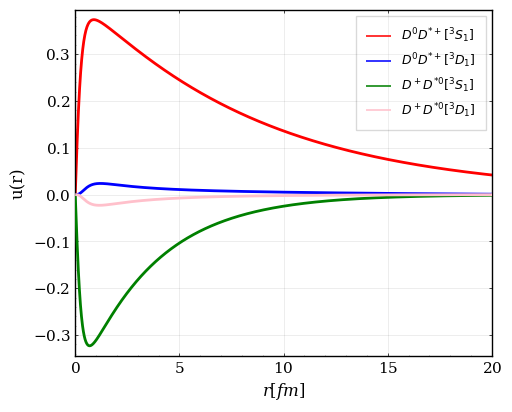

"/Users/linqiu/Nutstore Files/Nutstore/Projects/gitrepos/Tcc/SHE/images/she/wf_tcc.png"

In [70]:
let
    VMatT!(1.1645749348740693; I = 1, a = 0.0)
    eigvec_tmp = eigvecs(TMatT + VMatT + ΔMatT, NMatT)
    function wf(x; cl = 0, index = 1)
        tmp = 0.0
        for i in eachindex(νnt)
            tmp += eigvec_tmp[i+nmax*cl, index] * φ_gem(x, νnt[i], (cl % 2) * 2)
        end
        return tmp
    end
    rspan = 0.0:0.01:40.0
    id = 1
    sym = sign(real(wf(1.0; cl = 0, index = 1)))
    N = (integauss1d(r -> real(r * wf(r; cl = 0, index = id))^2) + integauss1d(r -> real(r * wf(r; cl = 1, index = id))^2)
         + integauss1d(r -> real(r * wf(r; cl = 2, index = id))^2) + integauss1d(r -> real(r * wf(r; cl = 3, index = id))^2))

    print(integauss1d(r -> real(r * wf(r; cl = 0, index = id))^2) / N, "\n")
    print(integauss1d(r -> real(r * wf(r; cl = 1, index = id))^2) / N, "\n")
    print(integauss1d(r -> real(r * wf(r; cl = 2, index = id))^2) / N, "\n")
    print(integauss1d(r -> real(r * wf(r; cl = 3, index = id))^2) / N, "\n")
    plot(xlabel = L"r[fm]",xlims=[0,20],size=(500,400),ylabel="u(r)")
    plot!(rspan, lc = :red,lw=2, r -> sym * real(r * wf(r; cl = 0, index = id)) / sqrt(N), label = L"D^0D^{*+}[^3S_1]")
    plot!(rspan, lc = :blue,lw=2, r -> sym * real(r * wf(r; cl = 1, index = id)) / sqrt(N), label = L"D^0D^{*+}[^3D_1]")
    plot!(rspan, lc = :green,lw=2, r -> sym * real(r * wf(r; cl = 2, index = id)) / sqrt(N), label = L"D^+D^{*0}[^3S_1]")
    plot!(rspan, lc = :pink,lw=2, r -> sym * real(r * wf(r; cl = 3, index = id)) / sqrt(N), label = L"D^+D^{*0}[^3D_1]")
    savefig("./images/she/wf_tcc.png")
end

##### a=1.0

In [71]:
let
    function tmpf(Λ; I = 0, a = 0.0)
        VMatT!(Λ; I = I, a = a)
        return eigvals(TMatT + VMatT + ΔMatT, NMatT)[1]
    end

    find_zero(x -> real(tmpf(x; I = 1, a = 1.0)) - (-0.273e-3), (1.0, 2.0))
end

1.3827377300876835

0.7333127938463052
0.0019484660409228628
0.2633678487929225
0.0013708913198495138


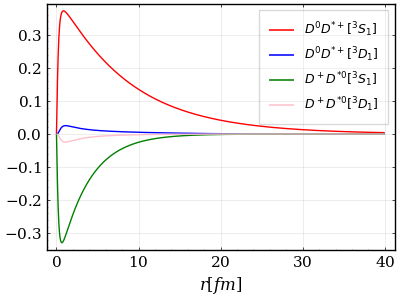

In [72]:
let
    VMatT!(1.3827377300876835; I = 1, a = 1.0)
    eigvec_tmp = eigvecs(TMatT + VMatT + ΔMatT, NMatT)
    function wf(x; cl = 0, index = 1)
        tmp = 0.0
        for i in eachindex(νnt)
            tmp += eigvec_tmp[i+nmax*cl, index] * φ_gem(x, νnt[i], (cl % 2) * 2)
        end
        return tmp
    end
    rspan = 0.0:0.01:40.0
    id = 1
    sym = sign(real(wf(1.0; cl = 0, index = 1)))
    N = (integauss1d(r -> real(r * wf(r; cl = 0, index = id))^2) + integauss1d(r -> real(r * wf(r; cl = 1, index = id))^2)
         + integauss1d(r -> real(r * wf(r; cl = 2, index = id))^2) + integauss1d(r -> real(r * wf(r; cl = 3, index = id))^2))

    print(integauss1d(r -> real(r * wf(r; cl = 0, index = id))^2) / N, "\n")
    print(integauss1d(r -> real(r * wf(r; cl = 1, index = id))^2) / N, "\n")
    print(integauss1d(r -> real(r * wf(r; cl = 2, index = id))^2) / N, "\n")
    print(integauss1d(r -> real(r * wf(r; cl = 3, index = id))^2) / N, "\n")
    plot(xlabel = L"r[fm]")
    plot!(rspan, lc = :red, r -> sym * real(r * wf(r; cl = 0, index = id)) / sqrt(N), label = L"D^0D^{*+}[^3S_1]")
    plot!(rspan, lc = :blue, r -> sym * real(r * wf(r; cl = 1, index = id)) / sqrt(N), label = L"D^0D^{*+}[^3D_1]")
    plot!(rspan, lc = :green, r -> sym * real(r * wf(r; cl = 2, index = id)) / sqrt(N), label = L"D^+D^{*0}[^3S_1]")
    plot!(rspan, lc = :pink, r -> sym * real(r * wf(r; cl = 3, index = id)) / sqrt(N), label = L"D^+D^{*0}[^3D_1]")
end

## $X(3872)$

In [60]:
ΔX = mDc + mDsc - mDn - mDsn

0.008180000000000298

In [61]:
ΔMatX = zeros(Float64, 4 * nmax, 4 * nmax);

In [62]:
for i in 1:1:nmax
    for j in 1:1:nmax
        ΔMatX[i+2*nmax, j+2*nmax] = ΔX * NMatrix_gem(νnt[i], νnt[j], 0)
        ΔMatX[i+3*nmax, j+3*nmax] = ΔX * NMatrix_gem(νnt[i], νnt[j], 2)
    end
end

In [63]:
NMatX = zeros(Float64, 4 * nmax, 4 * nmax);

In [64]:
for i in 1:1:nmax
    for j in 1:1:nmax
        NMatX[i, j] = NMatrix_gem(νnt[i], νnt[j], 0)
        NMatX[i+nmax, j+nmax] = NMatrix_gem(νnt[i], νnt[j], 2)
        NMatX[i+2*nmax, j+2*nmax] = NMatrix_gem(νnt[i], νnt[j], 0)
        NMatX[i+3*nmax, j+3*nmax] = NMatrix_gem(νnt[i], νnt[j], 2)
    end
end

In [65]:
TMatX = zeros(Float64, 4 * nmax, 4 * nmax);

In [66]:
for i in 1:1:nmax
    for j in 1:1:nmax
        TMatX[i, j] = TMatrix_gem(νnt[i], νnt[j], 0, μf(mDn, mDsn), hbarc)
        TMatX[i+nmax, j+nmax] = TMatrix_gem(νnt[i], νnt[j], 2, μf(mDn, mDsn), hbarc)
        TMatX[i+2*nmax, j+2*nmax] = TMatrix_gem(νnt[i], νnt[j], 0, μf(mDc, mDsc), hbarc)
        TMatX[i+3*nmax, j+3*nmax] = TMatrix_gem(νnt[i], νnt[j], 2, μf(mDc, mDsc), hbarc)
    end
end

In [67]:
VMatX = zeros(Float64, 4 * nmax, 4 * nmax);

In [68]:
function VMatX!(Λ; C = 1, a = 0.0)
    for i in 1:1:nmax
        for j in 1:1:nmax
            VMatX[i, j] = VMatrix_gem(r -> potential_Xn(r, Λ; C = C, a = a, st = [1.0, 0.0]), νnt[i], νnt[j], 0)
            VMatX[i, j+nmax] = VMatrix_gem(r -> potential_Xn(r, Λ; C = C, a = a, st = [0, -sqrt(2)]), νnt[i], νnt[j], 0)
            VMatX[i+nmax, j] = VMatrix_gem(r -> potential_Xn(r, Λ; C = C, a = a, st = [0, -sqrt(2)]), νnt[i], νnt[j], 2)
            VMatX[i+nmax, j+nmax] = VMatrix_gem(r -> potential_Xn(r, Λ; C = C, a = a, st = [1.0, 1.0]), νnt[i], νnt[j], 2)

            VMatX[i, j+2*nmax] = VMatrix_gem(r -> potential_Xcross(r, Λ; C = C, a = a, st = [1.0, 0.0]), νnt[i], νnt[j], 0)
            VMatX[i, j+3*nmax] = VMatrix_gem(r -> potential_Xcross(r, Λ; C = C, a = a, st = [0, -sqrt(2)]), νnt[i], νnt[j], 0)
            VMatX[i+nmax, j+2*nmax] = VMatrix_gem(r -> potential_Xcross(r, Λ; C = C, a = a, st = [0, -sqrt(2)]), νnt[i], νnt[j], 2)
            VMatX[i+nmax, j+3*nmax] = VMatrix_gem(r -> potential_Xcross(r, Λ; C = C, a = a, st = [1.0, 1.0]), νnt[i], νnt[j], 2)

            VMatX[i+2*nmax, j] = VMatrix_gem(r -> potential_Xcross(r, Λ; C = C, a = a, st = [1.0, 0.0]), νnt[i], νnt[j], 0)
            VMatX[i+2*nmax, j+nmax] = VMatrix_gem(r -> potential_Xcross(r, Λ; C = C, a = a, st = [0, -sqrt(2)]), νnt[i], νnt[j], 0)
            VMatX[i+3*nmax, j] = VMatrix_gem(r -> potential_Xcross(r, Λ; C = C, a = a, st = [0, -sqrt(2)]), νnt[i], νnt[j], 2)
            VMatX[i+3*nmax, j+nmax] = VMatrix_gem(r -> potential_Xcross(r, Λ; C = C, a = a, st = [1.0, 1.0]), νnt[i], νnt[j], 2)

            VMatX[i+2*nmax, j+2*nmax] = VMatrix_gem(r -> potential_Xc(r, Λ; C = C, a = a, st = [1.0, 0.0]), νnt[i], νnt[j], 0)
            VMatX[i+2*nmax, j+3*nmax] = VMatrix_gem(r -> potential_Xc(r, Λ; C = C, a = a, st = [0, -sqrt(2)]), νnt[i], νnt[j], 0)
            VMatX[i+3*nmax, j+2*nmax] = VMatrix_gem(r -> potential_Xc(r, Λ; C = C, a = a, st = [0, -sqrt(2)]), νnt[i], νnt[j], 2)
            VMatX[i+3*nmax, j+3*nmax] = VMatrix_gem(r -> potential_Xc(r, Λ; C = C, a = a, st = [1.0, 1.0]), νnt[i], νnt[j], 2)
        end
    end
end

VMatX! (generic function with 1 method)

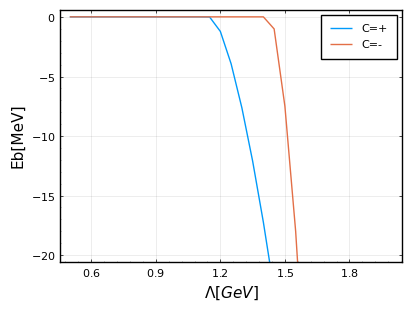

In [69]:
let
    function tmpf(Λ; C = 1, a = 0.0)
        VMatX!(Λ; C = C, a = a)
        return eigvals(TMatX + VMatX + ΔMatX, NMatX)[1]
    end

    plot(xlabel = L"\Lambda[GeV]",ylabel="Eb[MeV]", ylims = [-20, 0.0])
    plot!(0.5:0.05:2.0,x -> real(tmpf(x; C = 1))*1e3,  label = "C=+")
    plot!(0.5:0.05:2.0,x -> real(tmpf(x; C = -1))*1e3,  label = "C=-")
    savefig("./images/she/eb_dep_X.png")
end

In [71]:
3.87165 - mDn - mDsn

-4.000000000026205e-5

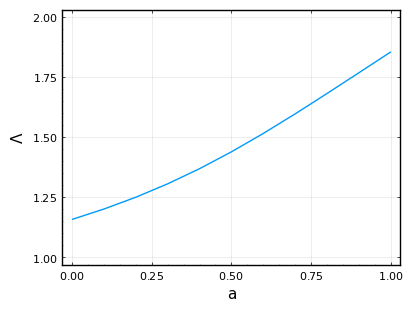

In [72]:
let
    function tmpf(Λ; C = 1, a = 0.0)
        VMatX!(Λ; C = C, a = a)
        return eigvals(TMatX + VMatX + ΔMatX, NMatX)[1]
    end

    function tmpf1(a)
        res = 0.0
        try
            res = find_zero(x -> (real(tmpf(x; C = 1, a = a)) - (3.87165 - mDn - mDsn)), (0.7, 2.0))
        catch
            res = NaN
        end
        return res
    end

    av = collect(0.0:0.1:1.0)
    Λv=tmpf1.(av)
    plot(av, Λv, xlabel = "a", ylabel = L"\Lambda", ylims = [1.0, 2.0], label = false)
    savefig("./images/she/lam_a_dep_X.png")
end

In [78]:
let
    function tmpf(Λ; C = 1, a = 0.0)
        VMatX!(Λ; C = C, a = a)
        return eigvals(TMatX + VMatX + ΔMatX, NMatX)[1]
    end

    function tmpf1(a)
        res = 0.0
        try
            res = find_zero(x -> (real(tmpf(x; C = 1, a = a)) - (3.87165 - mDn - mDsn)), (0.7, 2.0))
        catch
            res = NaN
        end
        return res
    end

    av = collect(0.0:0.1:1.0)
    global Λv2=tmpf1.(av)
end

11-element Vector{Float64}:
 1.1578019047097723
 1.201017787238104
 1.2501636894382655
 1.3060091382625978
 1.369043748972764
 1.439223922783263
 1.5157975106081787
 1.5973641931101812
 1.6821940456227842
 1.7686250407015847
 1.8553296237849268

##### a=0.0

In [73]:
let
    function tmpf(Λ; C = 1, a = 0.0)
        VMatX!(Λ; C = C, a = a)
        return eigvals(TMatX + VMatX + ΔMatX, NMatX)[1]
    end

    find_zero(x -> real(tmpf(x; C = 1, a = 0.0)) - (3.87165 - mDn - mDsn), (1.0, 1.2))
end

1.1577963735207488

0.9553900142714699
0.0007855982601043097
0.04327687818643383
0.0005475092819921721


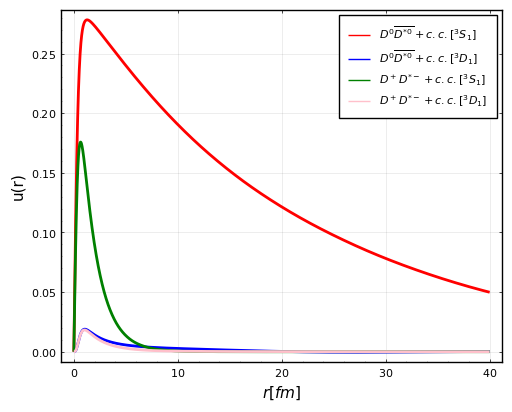

In [74]:
let
    VMatX!(1.1577963735207488; C = 1, a = 0.0)
    eigvec_tmp = eigvecs(TMatX + VMatX + ΔMatX, NMatX)
    function wf(x; cl = 0, index = 1)
        tmp = 0.0
        for i in eachindex(νnt)
            tmp += eigvec_tmp[i+nmax*cl, index] * φ_gem(x, νnt[i], (cl % 2) * 2)
        end
        return tmp
    end
    rspan = 0.0:0.01:40.0
    id = 1
    sym = sign(real(wf(1.0; cl = 0, index = 1)))
    N = (integauss1d(r -> real(r * wf(r; cl = 0, index = id))^2) + integauss1d(r -> real(r * wf(r; cl = 1, index = id))^2)
         + integauss1d(r -> real(r * wf(r; cl = 2, index = id))^2) + integauss1d(r -> real(r * wf(r; cl = 3, index = id))^2))

    print(integauss1d(r -> real(r * wf(r; cl = 0, index = id))^2) / N, "\n")
    print(integauss1d(r -> real(r * wf(r; cl = 1, index = id))^2) / N, "\n")
    print(integauss1d(r -> real(r * wf(r; cl = 2, index = id))^2) / N, "\n")
    print(integauss1d(r -> real(r * wf(r; cl = 3, index = id))^2) / N, "\n")
    plot(xlabel = L"r[fm]",xlims=[0,40],size=(500,400),ylabel="u(r)")
    plot!(rspan, lc = :red,lw=2, r -> sym * real(r * wf(r; cl = 0, index = id)) / sqrt(N), label = L"D^0\overline{D^{*0}}+c.c.[^3S_1]")
    plot!(rspan, lc = :blue,lw=2, r -> sym * real(r * wf(r; cl = 1, index = id)) / sqrt(N), label = L"D^0\overline{D^{*0}}+c.c.[^3D_1]")
    plot!(rspan, lc = :green,lw=2, r -> sym * real(r * wf(r; cl = 2, index = id)) / sqrt(N), label = L"D^+D^{*-}+c.c.[^3S_1]")
    plot!(rspan, lc = :pink,lw=2, r -> sym * real(r * wf(r; cl = 3, index = id)) / sqrt(N), label = L"D^+D^{*-}+c.c.[^3D_1]")
    savefig("./images/she/wf_X.png")
end

##### a=1.0

In [75]:
let
    function tmpf(Λ; C = 1, a = 0.0)
        VMatX!(Λ; C = C, a = a)
        return eigvals(TMatX + VMatX + ΔMatX, NMatX)[1]
    end

    find_zero(x -> real(tmpf(x; C = 1, a = 1.0)) - (3.87165 - mDn - mDsn), (1.0, 2.0))
end

1.855326276858371

0.9616195376922041
0.0009061090275210864
0.03682198243963205
0.0006523708406427436


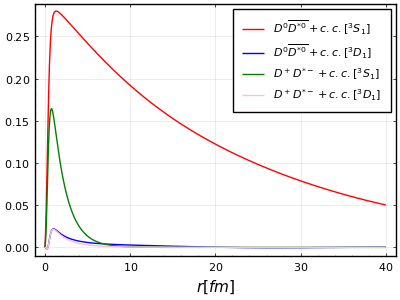

In [76]:
let
    VMatX!(1.855326276858371; C = 1, a = 1.0)
    eigvec_tmp = eigvecs(TMatX + VMatX + ΔMatX, NMatX)
    function wf(x; cl = 0, index = 1)
        tmp = 0.0
        for i in eachindex(νnt)
            tmp += eigvec_tmp[i+nmax*cl, index] * φ_gem(x, νnt[i], (cl % 2) * 2)
        end
        return tmp
    end
    rspan = 0.0:0.01:40.0
    id = 1
    sym = sign(real(wf(1.0; cl = 0, index = 1)))
    N = (integauss1d(r -> real(r * wf(r; cl = 0, index = id))^2) + integauss1d(r -> real(r * wf(r; cl = 1, index = id))^2)
         + integauss1d(r -> real(r * wf(r; cl = 2, index = id))^2) + integauss1d(r -> real(r * wf(r; cl = 3, index = id))^2))

    print(integauss1d(r -> real(r * wf(r; cl = 0, index = id))^2) / N, "\n")
    print(integauss1d(r -> real(r * wf(r; cl = 1, index = id))^2) / N, "\n")
    print(integauss1d(r -> real(r * wf(r; cl = 2, index = id))^2) / N, "\n")
    print(integauss1d(r -> real(r * wf(r; cl = 3, index = id))^2) / N, "\n")
    plot(xlabel = L"r[fm]")
    plot!(rspan, lc = :red, r -> sym * real(r * wf(r; cl = 0, index = id)) / sqrt(N), label = L"D^0\overline{D^{*0}}+c.c.[^3S_1]")
    plot!(rspan, lc = :blue, r -> sym * real(r * wf(r; cl = 1, index = id)) / sqrt(N), label = L"D^0\overline{D^{*0}}+c.c.[^3D_1]")
    plot!(rspan, lc = :green, r -> sym * real(r * wf(r; cl = 2, index = id)) / sqrt(N), label = L"D^+D^{*-}+c.c.[^3S_1]")
    plot!(rspan, lc = :pink, r -> sym * real(r * wf(r; cl = 3, index = id)) / sqrt(N), label = L"D^+D^{*-}+c.c.[^3D_1]")
end

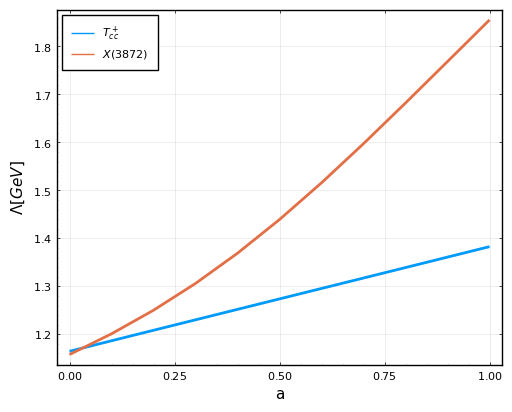

In [88]:
let av = collect(0.0:0.1:1.0)
    plot(xlabel="a",ylabel=L"\Lambda[GeV]",legend=:topleft,size=(500,400))
    plot!(av,Λv1,lw=2,label=L"T_{cc}^+")
    plot!(av,Λv2,lw=2,label=L"X(3872)")
    savefig("./images/lam_a.png")
end

## $Z_c(3900)$

In [77]:
ΔZ = mDc + mDsc - mDn - mDsn

0.008180000000000298

In [78]:
mDn + mDsn

3.87169

In [79]:
ΔMatZ = zeros(Float64, 4 * nmax, 4 * nmax);

In [80]:
for i in 1:1:nmax
    for j in 1:1:nmax
        ΔMatZ[i+2*nmax, j+2*nmax] = ΔZ * NMatrix_gem(νnt[i], νnt[j], 0)
        ΔMatZ[i+3*nmax, j+3*nmax] = ΔZ * NMatrix_gem(νnt[i], νnt[j], 2)
    end
end

In [81]:
NMatZ = zeros(Float64, 4 * nmax, 4 * nmax);

In [82]:
for i in 1:1:nmax
    for j in 1:1:nmax
        NMatZ[i, j] = NMatrix_gem(νnt[i], νnt[j], 0)
        NMatZ[i+nmax, j+nmax] = NMatrix_gem(νnt[i], νnt[j], 2)
        NMatZ[i+2*nmax, j+2*nmax] = NMatrix_gem(νnt[i], νnt[j], 0)
        NMatZ[i+3*nmax, j+3*nmax] = NMatrix_gem(νnt[i], νnt[j], 2)
    end
end

In [83]:
TMatZ = zeros(Float64, 4 * nmax, 4 * nmax);

In [84]:
for i in 1:1:nmax
    for j in 1:1:nmax
        TMatZ[i, j] = TMatrix_gem(νnt[i], νnt[j], 0, μf(mDn, mDsn), hbarc)
        TMatZ[i+nmax, j+nmax] = TMatrix_gem(νnt[i], νnt[j], 2, μf(mDn, mDsn), hbarc)
        TMatZ[i+2*nmax, j+2*nmax] = TMatrix_gem(νnt[i], νnt[j], 0, μf(mDc, mDsc), hbarc)
        TMatZ[i+3*nmax, j+3*nmax] = TMatrix_gem(νnt[i], νnt[j], 2, μf(mDc, mDsc), hbarc)
    end
end

In [85]:
VMatZ = zeros(Float64, 4 * nmax, 4 * nmax);

In [86]:
function VMatZ!(Λ; C = 1, a = 0.0)
    for i in 1:1:nmax
        for j in 1:1:nmax
            VMatZ[i, j] = VMatrix_gem(r -> potential_Xn(r, Λ; C = C, a = a, st = [1.0, 0.0]), νnt[i], νnt[j], 0)
            VMatZ[i, j+nmax] = VMatrix_gem(r -> potential_Xn(r, Λ; C = C, a = a, st = [0, -sqrt(2)]), νnt[i], νnt[j], 0)
            VMatZ[i+nmax, j] = VMatrix_gem(r -> potential_Xn(r, Λ; C = C, a = a, st = [0, -sqrt(2)]), νnt[i], νnt[j], 2)
            VMatZ[i+nmax, j+nmax] = VMatrix_gem(r -> potential_Xn(r, Λ; C = C, a = a, st = [1.0, 1.0]), νnt[i], νnt[j], 2)

            VMatZ[i, j+2*nmax] = VMatrix_gem(r -> potential_Xcross(r, Λ; C = C, a = a, st = [1.0, 0.0]), νnt[i], νnt[j], 0)
            VMatZ[i, j+3*nmax] = VMatrix_gem(r -> potential_Xcross(r, Λ; C = C, a = a, st = [0, -sqrt(2)]), νnt[i], νnt[j], 0)
            VMatZ[i+nmax, j+2*nmax] = VMatrix_gem(r -> potential_Xcross(r, Λ; C = C, a = a, st = [0, -sqrt(2)]), νnt[i], νnt[j], 2)
            VMatZ[i+nmax, j+3*nmax] = VMatrix_gem(r -> potential_Xcross(r, Λ; C = C, a = a, st = [1.0, 1.0]), νnt[i], νnt[j], 2)

            VMatZ[i+2*nmax, j] = VMatrix_gem(r -> potential_Xcross(r, Λ; C = C, a = a, st = [1.0, 0.0]), νnt[i], νnt[j], 0)
            VMatZ[i+2*nmax, j+nmax] = VMatrix_gem(r -> potential_Xcross(r, Λ; C = C, a = a, st = [0, -sqrt(2)]), νnt[i], νnt[j], 0)
            VMatZ[i+3*nmax, j] = VMatrix_gem(r -> potential_Xcross(r, Λ; C = C, a = a, st = [0, -sqrt(2)]), νnt[i], νnt[j], 2)
            VMatZ[i+3*nmax, j+nmax] = VMatrix_gem(r -> potential_Xcross(r, Λ; C = C, a = a, st = [1.0, 1.0]), νnt[i], νnt[j], 2)

            VMatZ[i+2*nmax, j+2*nmax] = VMatrix_gem(r -> potential_Xc(r, Λ; C = C, a = a, st = [1.0, 0.0]), νnt[i], νnt[j], 0)
            VMatZ[i+2*nmax, j+3*nmax] = VMatrix_gem(r -> potential_Xc(r, Λ; C = C, a = a, st = [0, -sqrt(2)]), νnt[i], νnt[j], 0)
            VMatZ[i+3*nmax, j+2*nmax] = VMatrix_gem(r -> potential_Xc(r, Λ; C = C, a = a, st = [0, -sqrt(2)]), νnt[i], νnt[j], 2)
            VMatZ[i+3*nmax, j+3*nmax] = VMatrix_gem(r -> potential_Xc(r, Λ; C = C, a = a, st = [1.0, 1.0]), νnt[i], νnt[j], 2)
        end
    end
end

VMatZ! (generic function with 1 method)

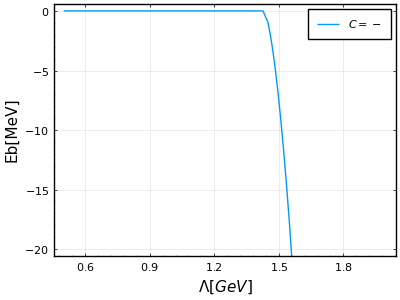

In [87]:
let
    function tmpf(Λ; C = 1, a = 0.0)
        VMatZ!(Λ; C = C, a = a)
        return eigvals(TMatZ + VMatZ + ΔMatZ, NMatZ)[1]
    end

    plot(xlabel = L"\Lambda[GeV]",ylabel="Eb[MeV]", ylims = [-20, 0.0])
    plot!(x -> real(tmpf(x; C = -1))*1e3, 0.5, 2.0, label = L"C=-")
end

# Solution of schrodinger equation(Partially)

In [41]:
nmax = 60;
νnt = [νnf(i, 0.01, 40.0, nmax) for i = 1:1:nmax];

In [42]:
global xxx,www;

In [43]:
function makegauss(n)
    global xxx, www = gauss(n, 0, 1)
end

makegauss (generic function with 1 method)

In [44]:
makegauss(128);

## $T_{cc}^+$

In [45]:
ΔT = mDc + mDsn - mDn - mDsc
ΔMatT = zeros(Float64, 4 * nmax, 4 * nmax);
for i in 1:1:nmax
    for j in 1:1:nmax
        ΔMatT[i+2*nmax, j+2*nmax] = ΔT * NMatrix_gem(νnt[i], νnt[j], 0)
        ΔMatT[i+3*nmax, j+3*nmax] = ΔT * NMatrix_gem(νnt[i], νnt[j], 2)
    end
end

NMatT = zeros(Float64, 4 * nmax, 4 * nmax);
for i in 1:1:nmax
    for j in 1:1:nmax
        NMatT[i, j] = NMatrix_gem(νnt[i], νnt[j], 0)
        NMatT[i+nmax, j+nmax] = NMatrix_gem(νnt[i], νnt[j], 2)
        NMatT[i+2*nmax, j+2*nmax] = NMatrix_gem(νnt[i], νnt[j], 0)
        NMatT[i+3*nmax, j+3*nmax] = NMatrix_gem(νnt[i], νnt[j], 2)
    end
end

TMatT = zeros(Float64, 4 * nmax, 4 * nmax);
for i in 1:1:nmax
    for j in 1:1:nmax
        TMatT[i, j] = TMatrix_gem(νnt[i], νnt[j], 0, μf(mDn, mDsc), hbarc)
        TMatT[i+nmax, j+nmax] = TMatrix_gem(νnt[i], νnt[j], 2, μf(mDn, mDsc), hbarc)
        TMatT[i+2*nmax, j+2*nmax] = TMatrix_gem(νnt[i], νnt[j], 0, μf(mDc, mDsn), hbarc)
        TMatT[i+3*nmax, j+3*nmax] = TMatrix_gem(νnt[i], νnt[j], 2, μf(mDc, mDsn), hbarc)
    end
end

In [46]:
VMatT = zeros(Float64, 4 * nmax, 4 * nmax);

In [47]:
function VMat_partial_T!(Λ; I = 0, a = 0.0,particle=["πc","πn"])
    for i in 1:1:nmax
        for j in 1:1:nmax
            VMatT[i, j] = VMatrix_gem(r -> potential_DnDsc(r, Λ; I = I, a = a, st = [1.0, 0.0],full=false,particle=particle), νnt[i], νnt[j], 0)
            VMatT[i, j+nmax] = VMatrix_gem(r -> potential_DnDsc(r, Λ; I = I, a = a, st = [0, -sqrt(2)],full=false,particle=particle), νnt[i], νnt[j], 0)
            VMatT[i+nmax, j] = VMatrix_gem(r -> potential_DnDsc(r, Λ; I = I, a = a, st = [0, -sqrt(2)],full=false,particle=particle), νnt[i], νnt[j], 2)
            VMatT[i+nmax, j+nmax] = VMatrix_gem(r -> potential_DnDsc(r, Λ; I = I, a = a, st = [1.0, 1.0],full=false,particle=particle), νnt[i], νnt[j], 2)
            VMatT[i, j+2*nmax] = VMatrix_gem(r -> potential_DDscross(r, Λ; I = I, a = a, st = [1.0, 0.0],full=false,particle=particle), νnt[i], νnt[j], 0)
            VMatT[i, j+3*nmax] = VMatrix_gem(r -> potential_DDscross(r, Λ; I = I, a = a, st = [0, -sqrt(2)],full=false,particle=particle), νnt[i], νnt[j], 0)
            VMatT[i+nmax, j+2*nmax] = VMatrix_gem(r -> potential_DDscross(r, Λ; I = I, a = a, st = [0, -sqrt(2)],full=false,particle=particle), νnt[i], νnt[j], 2)
            VMatT[i+nmax, j+3*nmax] = VMatrix_gem(r -> potential_DDscross(r, Λ; I = I, a = a, st = [1.0, 1.0],full=false,particle=particle), νnt[i], νnt[j], 2)
            VMatT[i+2*nmax, j] = VMatrix_gem(r -> potential_DDscross(r, Λ; I = I, a = a, st = [1.0, 0.0],full=false,particle=particle), νnt[i], νnt[j], 0)
            VMatT[i+2*nmax, j+nmax] = VMatrix_gem(r -> potential_DDscross(r, Λ; I = I, a = a, st = [0, -sqrt(2)],full=false,particle=particle), νnt[i], νnt[j], 0)
            VMatT[i+3*nmax, j] = VMatrix_gem(r -> potential_DDscross(r, Λ; I = I, a = a, st = [0, -sqrt(2)],full=false,particle=particle), νnt[i], νnt[j], 2)
            VMatT[i+3*nmax, j+nmax] = VMatrix_gem(r -> potential_DDscross(r, Λ; I = I, a = a, st = [1.0, 1.0],full=false,particle=particle), νnt[i], νnt[j], 2)
            VMatT[i+2*nmax, j+2*nmax] = VMatrix_gem(r -> potential_DcDsn(r, Λ; I = I, a = a, st = [1.0, 0.0],full=false,particle=particle), νnt[i], νnt[j], 0)
            VMatT[i+2*nmax, j+3*nmax] = VMatrix_gem(r -> potential_DcDsn(r, Λ; I = I, a = a, st = [0, -sqrt(2)],full=false,particle=particle), νnt[i], νnt[j], 0)
            VMatT[i+3*nmax, j+2*nmax] = VMatrix_gem(r -> potential_DcDsn(r, Λ; I = I, a = a, st = [0, -sqrt(2)],full=false,particle=particle), νnt[i], νnt[j], 2)
            VMatT[i+3*nmax, j+3*nmax] = VMatrix_gem(r -> potential_DcDsn(r, Λ; I = I, a = a, st = [1.0, 1.0],full=false,particle=particle), νnt[i], νnt[j], 2)
        end
    end
end

VMat_partial_T! (generic function with 1 method)

### only $pion$

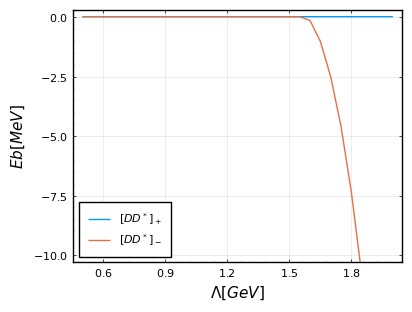

Base.IOError: IOError: stat("\\swapfile.sys"): resource busy or locked (EBUSY)

In [55]:
let
    function tmpf(Λ; I = 0, a = 0.0)
        VMat_partial_T!(Λ; I = I, a = a,particle=["πc","πn"])
        return eigvals(TMatT + VMatT + ΔMatT, NMatT)[1]
    end

    plot(xlabel = L"\Lambda[GeV]",ylabel=L"Eb[MeV]", ylims = [-10, 0.0],legend=:bottomleft)
    plot!(0.5:0.05:2.0,x -> real(tmpf(x; I = 0))*1e3, label = L"[DD^*]_+")
    plot!(0.5:0.05:2.0,x -> real(tmpf(x; I = 1))*1e3, label = L"[DD^*]_-")
    savefig("./images/she/eb_dep_op_tcc.png")
end

In [51]:
let
    function tmpf(Λ; I = 0, a = 0.0)
        VMat_partial_T!(Λ; I = I, a = a,particle=["πc","πn"])
        return eigvals(TMatT + VMatT + ΔMatT, NMatT)[1]
    end

    tmpf(1.1645749370503484;I=1)
end

1.378351013495842e-5

In [52]:
let
    function tmpf(Λ; I = 0, a = 0.0)
        VMat_partial_T!(Λ; I = I, a = a,particle=["πc","πn"])
        return eigvals(TMatT + VMatT + ΔMatT, NMatT)[1]
    end

    find_zero(x -> real(tmpf(x; I = 1)) - (-0.273e-3), (1.0, 1.8))
end

1.6102890549448243

0.7495734679961469
0.0026150689535264613
0.24588594887824206
0.0019255141720846112


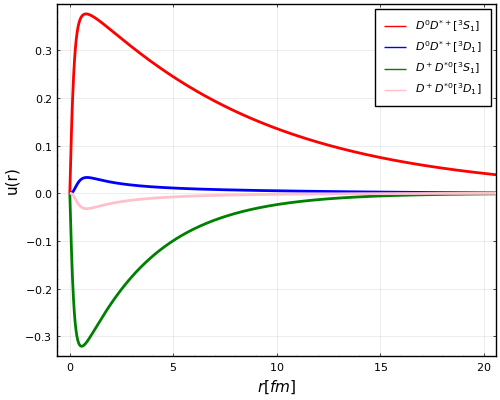

In [53]:
let
    VMat_partial_T!(1.6102890549448243; I = 1, a = 0.0,particle=["πc","πn"])
    eigvec_tmp = eigvecs(TMatT + VMatT + ΔMatT, NMatT)
    function wf(x; cl = 0, index = 1)
        tmp = 0.0
        for i in eachindex(νnt)
            tmp += eigvec_tmp[i+nmax*cl, index] * φ_gem(x, νnt[i], (cl % 2) * 2)
        end
        return tmp
    end
    rspan = 0.0:0.01:40.0
    id = 1
    sym = sign(real(wf(1.0; cl = 0, index = 1)))
    N = (integauss1d(r -> real(r * wf(r; cl = 0, index = id))^2) + integauss1d(r -> real(r * wf(r; cl = 1, index = id))^2)
         + integauss1d(r -> real(r * wf(r; cl = 2, index = id))^2) + integauss1d(r -> real(r * wf(r; cl = 3, index = id))^2))

    print(integauss1d(r -> real(r * wf(r; cl = 0, index = id))^2) / N, "\n")
    print(integauss1d(r -> real(r * wf(r; cl = 1, index = id))^2) / N, "\n")
    print(integauss1d(r -> real(r * wf(r; cl = 2, index = id))^2) / N, "\n")
    print(integauss1d(r -> real(r * wf(r; cl = 3, index = id))^2) / N, "\n")
    plot(xlabel = L"r[fm]",xlims=[0,20],size=(500,400),ylabel="u(r)")
    plot!(rspan, lc = :red,lw=2, r -> sym * real(r * wf(r; cl = 0, index = id)) / sqrt(N), label = L"D^0D^{*+}[^3S_1]")
    plot!(rspan, lc = :blue,lw=2, r -> sym * real(r * wf(r; cl = 1, index = id)) / sqrt(N), label = L"D^0D^{*+}[^3D_1]")
    plot!(rspan, lc = :green,lw=2, r -> sym * real(r * wf(r; cl = 2, index = id)) / sqrt(N), label = L"D^+D^{*0}[^3S_1]")
    plot!(rspan, lc = :pink,lw=2, r -> sym * real(r * wf(r; cl = 3, index = id)) / sqrt(N), label = L"D^+D^{*0}[^3D_1]")
end

### only heavier mesons

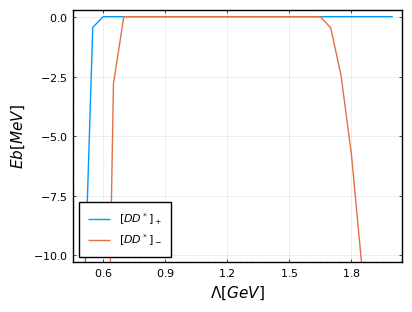

In [69]:
let
    function tmpf(Λ; I = 0, a = 0.0)
        VMat_partial_T!(Λ; I = I, a = a,particle=["ρc","ρn","η","ω","σ"])
        return eigvals(TMatT + VMatT + ΔMatT, NMatT)[1]
    end

    plot(xlabel = L"\Lambda[GeV]",ylabel=L"Eb[MeV]", ylims = [-10, 0.0],legend=:bottomleft)
    plot!(0.5:0.05:2.0,x -> real(tmpf(x; I = 0))*1e3, label = L"[DD^*]_+")
    plot!(0.5:0.05:2.0,x -> real(tmpf(x; I = 1))*1e3, label = L"[DD^*]_-")
    savefig("./images/she/eb_dep_oh_tcc.png")
end

In [70]:
let
    function tmpf(Λ; I = 0, a = 0.0)
        VMat_partial_T!(Λ; I = I, a = a,particle=["ρc","ρn","η","ω","σ"])
        return eigvals(TMatT + VMatT + ΔMatT, NMatT)[1]
    end

    find_zero(x -> real(tmpf(x; I = 1)) - (-0.273e-3), (1.0, 1.8))
end

1.6924645789749875

In [56]:
let
    function tmpf(Λ; I = 0, a = 0.0)
        VMat_partial_T!(Λ; I = I, a = a,particle=["ρc","ρn","ω","σ","η"])
        return eigvals(TMatT + VMatT + ΔMatT, NMatT)[1]
    end

    tmpf(1.1645749370503484;I=1)
end

1.405961446299461e-5 + 0.0im

## $X(3872)$

In [57]:
ΔX = mDc + mDsc - mDn - mDsn;
ΔMatX = zeros(Float64, 4 * nmax, 4 * nmax);
for i in 1:1:nmax
    for j in 1:1:nmax
        ΔMatX[i+2*nmax, j+2*nmax] = ΔX * NMatrix_gem(νnt[i], νnt[j], 0)
        ΔMatX[i+3*nmax, j+3*nmax] = ΔX * NMatrix_gem(νnt[i], νnt[j], 2)
    end
end

NMatX = zeros(Float64, 4 * nmax, 4 * nmax);
for i in 1:1:nmax
    for j in 1:1:nmax
        NMatX[i, j] = NMatrix_gem(νnt[i], νnt[j], 0)
        NMatX[i+nmax, j+nmax] = NMatrix_gem(νnt[i], νnt[j], 2)
        NMatX[i+2*nmax, j+2*nmax] = NMatrix_gem(νnt[i], νnt[j], 0)
        NMatX[i+3*nmax, j+3*nmax] = NMatrix_gem(νnt[i], νnt[j], 2)
    end
end

TMatX = zeros(Float64, 4 * nmax, 4 * nmax);
for i in 1:1:nmax
    for j in 1:1:nmax
        TMatX[i, j] = TMatrix_gem(νnt[i], νnt[j], 0, μf(mDn, mDsn), hbarc)
        TMatX[i+nmax, j+nmax] = TMatrix_gem(νnt[i], νnt[j], 2, μf(mDn, mDsn), hbarc)
        TMatX[i+2*nmax, j+2*nmax] = TMatrix_gem(νnt[i], νnt[j], 0, μf(mDc, mDsc), hbarc)
        TMatX[i+3*nmax, j+3*nmax] = TMatrix_gem(νnt[i], νnt[j], 2, μf(mDc, mDsc), hbarc)
    end
end

In [58]:
VMatX = zeros(Float64, 4 * nmax, 4 * nmax);

In [63]:
function VMat_partial_X!(Λ; C = 1, a = 0.0,particle=["π"])
    for i in 1:1:nmax
        for j in 1:1:nmax
            VMatX[i, j] = VMatrix_gem(r -> potential_Xn(r, Λ; C = C, a = a, st = [1.0, 0.0],full=false,particle=particle), νnt[i], νnt[j], 0)
            VMatX[i, j+nmax] = VMatrix_gem(r -> potential_Xn(r, Λ; C = C, a = a, st = [0, -sqrt(2)],full=false,particle=particle), νnt[i], νnt[j], 0)
            VMatX[i+nmax, j] = VMatrix_gem(r -> potential_Xn(r, Λ; C = C, a = a, st = [0, -sqrt(2)],full=false,particle=particle), νnt[i], νnt[j], 2)
            VMatX[i+nmax, j+nmax] = VMatrix_gem(r -> potential_Xn(r, Λ; C = C, a = a, st = [1.0, 1.0],full=false,particle=particle), νnt[i], νnt[j], 2)

            VMatX[i, j+2*nmax] = VMatrix_gem(r -> potential_Xcross(r, Λ; C = C, a = a, st = [1.0, 0.0],full=false,particle=particle), νnt[i], νnt[j], 0)
            VMatX[i, j+3*nmax] = VMatrix_gem(r -> potential_Xcross(r, Λ; C = C, a = a, st = [0, -sqrt(2)],full=false,particle=particle), νnt[i], νnt[j], 0)
            VMatX[i+nmax, j+2*nmax] = VMatrix_gem(r -> potential_Xcross(r, Λ; C = C, a = a, st = [0, -sqrt(2)],full=false,particle=particle), νnt[i], νnt[j], 2)
            VMatX[i+nmax, j+3*nmax] = VMatrix_gem(r -> potential_Xcross(r, Λ; C = C, a = a, st = [1.0, 1.0],full=false,particle=particle), νnt[i], νnt[j], 2)

            VMatX[i+2*nmax, j] = VMatrix_gem(r -> potential_Xcross(r, Λ; C = C, a = a, st = [1.0, 0.0],full=false,particle=particle), νnt[i], νnt[j], 0)
            VMatX[i+2*nmax, j+nmax] = VMatrix_gem(r -> potential_Xcross(r, Λ; C = C, a = a, st = [0, -sqrt(2)],full=false,particle=particle), νnt[i], νnt[j], 0)
            VMatX[i+3*nmax, j] = VMatrix_gem(r -> potential_Xcross(r, Λ; C = C, a = a, st = [0, -sqrt(2)],full=false,particle=particle), νnt[i], νnt[j], 2)
            VMatX[i+3*nmax, j+nmax] = VMatrix_gem(r -> potential_Xcross(r, Λ; C = C, a = a, st = [1.0, 1.0],full=false,particle=particle), νnt[i], νnt[j], 2)

            VMatX[i+2*nmax, j+2*nmax] = VMatrix_gem(r -> potential_Xc(r, Λ; C = C, a = a, st = [1.0, 0.0],full=false,particle=particle), νnt[i], νnt[j], 0)
            VMatX[i+2*nmax, j+3*nmax] = VMatrix_gem(r -> potential_Xc(r, Λ; C = C, a = a, st = [0, -sqrt(2)],full=false,particle=particle), νnt[i], νnt[j], 0)
            VMatX[i+3*nmax, j+2*nmax] = VMatrix_gem(r -> potential_Xc(r, Λ; C = C, a = a, st = [0, -sqrt(2)],full=false,particle=particle), νnt[i], νnt[j], 2)
            VMatX[i+3*nmax, j+3*nmax] = VMatrix_gem(r -> potential_Xc(r, Λ; C = C, a = a, st = [1.0, 1.0],full=false,particle=particle), νnt[i], νnt[j], 2)
        end
    end
end

VMat_partial_X! (generic function with 1 method)

### only $pion$

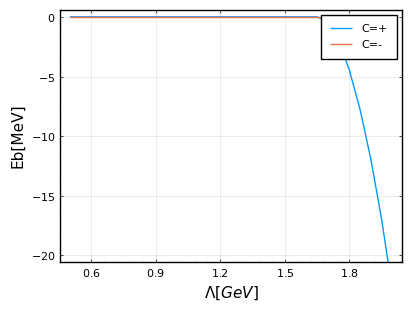

In [64]:
let
    function tmpf(Λ; C = 1, a = 0.0)
        VMat_partial_X!(Λ; C = C, a = a,particle=["π"])
        return eigvals(TMatX + VMatX + ΔMatX, NMatX)[1]
    end

    plot(xlabel = L"\Lambda[GeV]",ylabel="Eb[MeV]", ylims = [-20, 0.0])
    plot!(0.5:0.05:2.0,x -> real(tmpf(x; C = 1))*1e3,  label = "C=+")
    plot!(0.5:0.05:2.0,x -> real(tmpf(x; C = -1))*1e3,  label = "C=-")
    savefig("./images/she/eb_dep_op_X.png")
end

In [66]:
let
    function tmpf(Λ; C = 1, a = 0.0)
        VMat_partial_X!(Λ; C = C, a = a,particle=["π"])
        return eigvals(TMatX + VMatX + ΔMatX, NMatX)[1]
    end

    find_zero(x -> real(tmpf(x; C = 1, a = 0.0)) - (3.87165 - mDn - mDsn), (1.5, 1.8))
end

1.6779695145520996

Base.IOError: IOError: stat("\\swapfile.sys"): resource busy or locked (EBUSY)

In [65]:
let
    function tmpf(Λ; C = 1, a = 0.0)
        VMat_partial_X!(Λ; C = C, a = a,particle=["π"])
        return eigvals(TMatX + VMatX + ΔMatX, NMatX)[1]
    end
    tmpf(1.1577963735207488)
end

1.3996879046555608e-5

### only heavier mesons

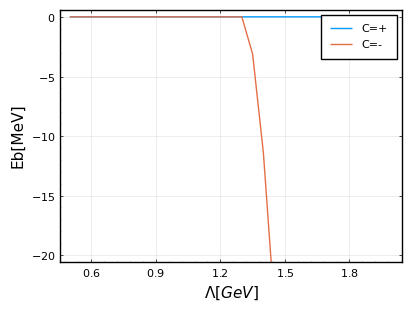

In [71]:
let
    function tmpf(Λ; C = 1, a = 0.0)
        VMat_partial_X!(Λ; C = C, a = a,particle=["ρ","ω","σ","η"])
        return eigvals(TMatX + VMatX + ΔMatX, NMatX)[1]
    end

    plot(xlabel = L"\Lambda[GeV]",ylabel="Eb[MeV]", ylims = [-20, 0.0])
    plot!(0.5:0.05:2.0,x -> real(tmpf(x; C = 1))*1e3,  label = "C=+")
    plot!(0.5:0.05:2.0,x -> real(tmpf(x; C = -1))*1e3,  label = "C=-")
    savefig("./images/she/eb_dep_oh_X.png")
end

In [68]:
let
     function tmpf(Λ; C = 1, a = 0.0)
        VMat_partial_X!(Λ; C = C, a = a,particle=["ρ","ω","σ","η"])
        return eigvals(TMatX + VMatX + ΔMatX, NMatX)[1]
    end
    tmpf(1.1577963735207488)
end

1.4008967492569343e-5 + 0.0im

Base.IOError: IOError: stat("\\swapfile.sys"): resource busy or locked (EBUSY)